In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
%matplotlib inline
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import networkx as nx
from statsmodels.nonparametric.smoothers_lowess import lowess

In [2]:

import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import read_qc_file

qc_data = read_qc_file(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\QC_msmetrix.xlsx"
)


 File successfully read as Excel (.xlsx)

 Preview of QC data:
   Peak    tR1    tR2     tR  m/z  \
0     1  1.864  1.949  1.906   40   
1     2  1.905  1.991  1.948   44   
2     3  1.925  2.003  1.964   81   
3     4  1.940  2.039  1.990   64   
4     5  1.960  2.090  2.025   42   

                                            ID Names  s1 S96_QC1_B1_D1_T1  \
0    0.15%  || 40                                ...                44728   
1    1.81%  || 44                                ...               354392   
2    0.14%  || 81   69  169  119                 ...                75703   
3    0.80%  || 64   48   61   66   96   37  131  ...               238856   
4    0.82%  || 42  41  40  39  38  50            ...               207592   

   s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  ...  \
0                46928                46096                44488  ...   
1               461936               609704                92652  ...   
2                27041          

# Since T1 and T2 were the repeated experiments and the peaks have overlap I just used T1.

In [3]:
# Clean column names (remove spaces)
qc_data.columns = qc_data.columns.str.strip()

# consider Metadata columns
metadata_cols = ['Peak', 'tR1', 'tR2', 'tR', 'm/z']

# Select columns that end with "T1"
t1_cols = [c for c in qc_data.columns if c.strip().endswith("T1")]

# Combine metadata + T1 columns
qc_data_T1 = qc_data[metadata_cols + t1_cols]

# Show results
print("Selected T1 sample columns:")
print(t1_cols)
print("\nFiltered DataFrame shape:", qc_data_T1.shape)
print(qc_data_T1.head())

Selected T1 sample columns:
['s1 S96_QC1_B1_D1_T1', 's2 S96_QC2_B1_D1_T1', 's3 S96_QC3_B1_D1_T1', 's4 S96_QC4_B1_D1_T1', 's5 S96_QC1_B1_D2_T1', 's6 S96_QC2_B1_D2_T1', 's7 S96_QC3_B1_D2_T1', 's8 S96_QC4_B1_D2_T1', 's9 S96_QC1_B1_D3_T1', 's10 S96_QC2_B1_D3_T1', 's11 S96_QC3_B1_D3_T1', 's12 S96_QC4_B1_D3_T1', 's13 S96_QC2_B1_D4_T1', 's14 S96_QC3_B1_D4_T1', 's15 S96_QC4_B1_D4_T1', 's16 S96_QC1_B1_D4_T1', 's17 S96_QC1_B1_D5_T1', 's18 S96_QC1_B1_D9_T1', 's19 S96_QC2_B1_D5_T1', 's20 S96_QC2_B1_D9_T1', 's21 S96_QC3_B1_D5_T1', 's22 S96_QC3_B1_D9_T1', 's23 S96_QC4_B1_D5_T1', 's24 S96_QC4_B1_D9_T1', 's25 S96_QC1_B1_D10_T1', 's26 S96_QC1_B1_D6_T1', 's27 S96_QC1_B1_D7_T1', 's28 S96_QC1_B1_D8_T1', 's29 S96_QC3_B1_D10_T1', 's30 S96_QC3_B1_D6_T1', 's31 S96_QC3_B1_D7_T1', 's32 S96_QC4_B1_D10_T1', 's33 S96_QC4_B1_D6_T1', 's34 S96_QC4_B1_D7_T1', 's35 S96_QC2_B1_D8_T1', 's36 S96_QC3_B1_D8_T1', 's37 S96_QC4_B1_D8_T1', 's38 S96_QC2_B1_D10_T1', 's39 S96_QC2_B1_D6_T1', 's40 S96_QC2_B1_D7_T1']

Filtered DataFr

In [4]:
# we got the information of qcdata to see more details qc data inlcudes four qc including QC1, QC2, QC3 and QC4
qc_data_T1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 45 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Peak                   589 non-null    int64  
 1   tR1                    589 non-null    float64
 2   tR2                    589 non-null    float64
 3   tR                     589 non-null    float64
 4   m/z                    589 non-null    int64  
 5   s1 S96_QC1_B1_D1_T1    589 non-null    int64  
 6   s2 S96_QC2_B1_D1_T1    589 non-null    int64  
 7   s3 S96_QC3_B1_D1_T1    589 non-null    int64  
 8   s4 S96_QC4_B1_D1_T1    589 non-null    int64  
 9   s5 S96_QC1_B1_D2_T1    589 non-null    int64  
 10  s6 S96_QC2_B1_D2_T1    589 non-null    int64  
 11  s7 S96_QC3_B1_D2_T1    589 non-null    int64  
 12  s8 S96_QC4_B1_D2_T1    589 non-null    int64  
 13  s9 S96_QC1_B1_D3_T1    589 non-null    int64  
 14  s10 S96_QC2_B1_D3_T1   589 non-null    int64  
 15  s11 S9

In [5]:

# Since we had three retention time in our qc data derived from msmetrix ,  we got differences between retention time beacuse we want to have just one retention time
diff_t_vs_1 = (qc_data_T1['tR'] -qc_data_T1['tR1']).abs()
diff_t_vs_2 = (qc_data_T1['tR'] - qc_data_T1['tR2']).abs()
diff_1_vs_2 = (qc_data_T1['tR1'] -qc_data_T1['tR2']).abs()
avg_t   = (qc_data_T1['tR1'] + qc_data_T1['tR2']) / 2
diff_avg_vs_t = (avg_t - qc_data['tR']).abs()

# printing the results
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    589.000000
mean       0.033163
std        0.018089
min        0.015000
25%        0.021000
50%        0.027000
75%        0.039000
max        0.141000
dtype: float64 

abs(tR - tR2):
 count    589.000000
mean       0.033136
std        0.018078
min        0.015000
25%        0.021000
50%        0.027000
75%        0.038000
max        0.141000
dtype: float64 

abs(tR1 - tR2):
 count    589.000000
mean       0.066299
std        0.036161
min        0.030000
25%        0.042000
50%        0.053000
75%        0.077000
max        0.282000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    5.890000e+02
mean     2.393888e-04
std      2.499870e-04
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      5.000000e-04
max      5.000000e-04
dtype: float64 



The two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.

In [6]:
# put TR as tR_best instead of other tr
qc_data_T1['tR_best'] = (qc_data_T1['tR1'] + qc_data_T1['tR2']) / 2

# removing unnecessary columns
to_keep = [col for col in qc_data_T1.columns if col not in ['tR1', 'tR2', 'tR']]
cleaned_qc = qc_data_T1[to_keep]

# Confirm that 'tR_best' is included
print("tR_best column saved:", 'tR_best' in cleaned_qc.columns)

cols = cleaned_qc.columns.tolist()
# Moving 'tR_best' after 'Peak'
cols.insert(cols.index('Peak') + 1, cols.pop(cols.index('tR_best')))

# Reorder the DataFrame
cleaned_qc = cleaned_qc[cols]
# Check the result
print(cleaned_qc.head())
# Save cleaned data with tR_best
cleaned_qc.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\cleaned_qc.csv", index=False)
# now this cleaned_qc datafram can be used for further analysis

tR_best column saved: True
   Peak  tR_best  m/z  s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  \
0     1   1.9065   40                44728                46928   
1     2   1.9480   44               354392               461936   
2     3   1.9640   81                75703                27041   
3     4   1.9895   64               238856               296333   
4     5   2.0250   42               207592               197912   

   s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  s5 S96_QC1_B1_D2_T1  \
0                46096                44488                47288   
1               609704                92652               326936   
2                69053                62942                41856   
3               363394               280169               239716   
4               201184               105097               226030   

   s6 S96_QC2_B1_D2_T1  s7 S96_QC3_B1_D2_T1  ...  s31 S96_QC3_B1_D7_T1  \
0                46560                45104  ...                 45912   
1            

This dataframe includes three metadata column and 40 qc samples

for samples we just used T1 from our sample data beacuse T1 and T2 were the experiments with the same peaks and they were reproducible. just in two case our samples data had problem and we used T2(sample 46, 47)

# Preparing the samples derived by MS-metrix after GC-MS


In [7]:
# Load data
input_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\final_sample_1-10.xlsx"
df_raw = pd.read_excel(input_path, header=None)

# Find the header row that contains "Peak"
header_row = df_raw[df_raw.iloc[:, 0].astype(str).str.strip() == "Peak"].index[0]
potato_data = pd.read_excel(input_path, header=header_row)

# Metadata columns to keep
metadata_cols = ['Peak', 'tR1', 'tR2', 'tR', 'm/z']

# Define normalized list of sample IDs that we want to keep
final_normalized_ids = [
    'S96_10_B1_D2_T1', 'S96_11_B1_D10_T1', 'S96_12_B1_D5_T1', 'S96_13_B1_D9_T1',
    'S96_14_B1_D1_T1', 'S96_15_B1_D6_T1', 'S96_16_B1_D3_T1', 'S96_17_B1_D9_T1',
    'S96_18_B1_D4_T1', 'S96_19_B1_D10_T1', 'S96_1_B1_D5_T1', 'S96_20_B1_D9_T1',
    'S96_21_B1_D1_T1', 'S96_22_B1_D8_T1', 'S96_23_B1_D9_T1', 'S96_24_B1_D7_T1',
    'S96_25_B1_D6_T1', 'S96_26_B1_D8_T1', 'S96_27_B1_D9_T1', 'S96_28_B1_D1_T1',
    'S96_29_B1_D9_T1', 'S96_2_B1_D7_T1', 'S96_30_B1_D5_T1', 'S96_31_B1_D7_T1',
    'S96_32_B1_D7_T1', 'S96_33_B1_D10_T1', 'S96_34_B1_D7_T1', 'S96_35_B1_D5_T1',
    'S96_36_B1_D5_T1', 'S96_37_B1_D4_T1', 'S96_38_B1_D2_T1', 'S96_39_B1_D3_T1',
    'S96_3_B1_D9_T1', 'S96_40_B1_D6_T1', 'S96_41_B1_D6_T1', 'S96_42_B1_D2_T1',
    'S96_43_B1_D4_T1', 'S96_44_B1_D1_T1', 'S96_45_B1_D6_T1', 'S96_46_B1_D10_T2',
    'S96_47_B1_D8_T2', 'S96_48_B1_D2_T1', 'S96_49_B1_D6_T1', 'S96_4_B1_D4_T1',
    'S96_50_B1_D3_T1', 'S96_51_B1_D4_T1', 'S96_52_B1_D8_T1', 'S96_53_B1_D1_T1',
    'S96_54_B1_D8_T1', 'S96_55_B1_D1_T1', 'S96_56_B1_D2_T1', 'S96_57_B1_D4_T1',
    'S96_58_B1_D7_T1', 'S96_59_B1_D6_T1', 'S96_5_B1_D3_T1', 'S96_60_B1_D3_T1',
    'S96_61_B1_D4_T1', 'S96_62_B1_D9_T1', 'S96_63_B1_D10_T1', 'S96_64_B1_D7_T1',
    'S96_65_B1_D8_T1', 'S96_66_B1_D3_T1', 'S96_67_B1_D8_T1', 'S96_68_B1_D3_T1',
    'S96_69_B1_D10_T1', 'S96_6_B1_D2_T1', 'S96_70_B1_D7_T1', 'S96_71_B1_D5_T1',
    'S96_72_B1_D9_T1', 'S96_73_B1_D5_T1', 'S96_74_B1_D6_T1', 'S96_75_B1_D4_T1',
    'S96_76_B1_D2_T1', 'S96_77_B1_D6_T1', 'S96_78_B1_D7_T1', 'S96_79_B1_D2_T1',
    'S96_7_B1_D1_T1', 'S96_80_B1_D8_T1', 'S96_81_B1_D3_T1', 'S96_82_B1_D8_T1',
    'S96_83_B1_D1_T1', 'S96_84_B1_D10_T1', 'S96_85_B1_D8_T1', 'S96_86_B1_D2_T1',
    'S96_87_B1_D3_T1', 'S96_88_B1_D5_T1', 'S96_89_B1_D10_T1', 'S96_8_B1_D4_T1',
    'S96_90_B1_D7_T1', 'S96_91_B1_D10_T1', 'S96_92_B1_D1_T1', 'S96_93_B1_D5_T1',
    'S96_94_B1_D4_T1', 'S96_9_B1_D1_T1'
]


# Get all sample columns but not metadata
sample_cols = [c for c in potato_data.columns if c not in metadata_cols and c != "ID Names"]

# Map actual column names to normalized sample IDs
def normalize_id(col):
    sid = col.split()[1]
    sid = re.sub(r'_T[0-9]+_', '_', sid)
    parts = sid.split("_")
    cleaned = []
    for p in parts:
        if re.fullmatch(r'T[0-9]+', p) and p not in ['T1', 'T2']:
            continue
        cleaned.append(p)
    return "_".join(cleaned)

# Create a mapping of normalized ID 
norm_to_col = {normalize_id(c): c for c in sample_cols}

# Select the actual column names corresponding to desired 94 normalized IDs
selected_columns = [norm_to_col[nid] for nid in final_normalized_ids if nid in norm_to_col]

# Create the filtered dataset with metadata and 94 sample columns 
potato_data_filtered = potato_data[metadata_cols + selected_columns]

# Save or return result 
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\potato_data_filtered_94_samples.xlsx"
potato_data_filtered.to_excel(output_path, index=False)
print(f"\nDataset saved with {len(selected_columns)} samples + metadata columns.")



Dataset saved with 94 samples + metadata columns.


In [8]:
#  Checking to see if we have missing value or not
potato_data_filtered.isnull().sum()

Peak                     0
tR1                      0
tR2                      0
tR                       0
m/z                      0
                        ..
s173 S96_91_B1_D10_T1    0
s5 S96_92_B1_D1_T1       0
s82 S96_93_B1_D5_T1      0
s64 S96_94_B1_D4_T1      0
s3 S96_9_B1_D1_T1        0
Length: 99, dtype: int64

like qc the samples derived from MsMetrix had three retention time we selected one of them as the same as qc

In [9]:

# getting the differences to find the realation between retention times
diff_t_vs_1 = (potato_data_filtered['tR'] - potato_data_filtered['tR1']).abs()
diff_t_vs_2 = (potato_data_filtered['tR'] -potato_data_filtered['tR2']).abs()
diff_1_vs_2 = (potato_data_filtered['tR1'] - potato_data_filtered['tR2']).abs()
avg_t   = (potato_data_filtered['tR1'] + potato_data_filtered['tR2']) / 2
diff_avg_vs_t = (avg_t -potato_data_filtered['tR']).abs()

#  the results
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    602.000000
mean       0.054683
std        0.037511
min        0.016000
25%        0.031000
50%        0.045000
75%        0.068000
max        0.373000
dtype: float64 

abs(tR - tR2):
 count    602.000000
mean       0.054701
std        0.037530
min        0.016000
25%        0.030250
50%        0.045000
75%        0.068000
max        0.373000
dtype: float64 

abs(tR1 - tR2):
 count    602.000000
mean       0.109384
std        0.075038
min        0.032000
25%        0.061000
50%        0.090000
75%        0.136000
max        0.746000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    602.000000
mean       0.000253
std        0.000250
min        0.000000
25%        0.000000
50%        0.000500
75%        0.000500
max        0.000500
dtype: float64 




the two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.


In [10]:
# Rename tR to tR_best 
selected_data = potato_data_filtered.rename(columns={'tR': 'tR_best'})
# Select only columns we need them
columns_to_keep = ['Peak', 'tR_best', 'm/z'] + [c for c in selected_data.columns if c.startswith('s')]
selected_data = selected_data[columns_to_keep].copy()

print("Selected data shape:", selected_data.shape)
display(selected_data.head(10))



Selected data shape: (602, 97)


,Peak,tR_best,m/z,s26 S96_10_B1_D2_T1,s169 S96_11_B1_D10_T1,s78 S96_12_B1_D5_T1,s153 S96_13_B1_D9_T1,s2 S96_14_B1_D1_T1,s93 S96_15_B1_D6_T1,s39 S96_16_B1_D3_T1,...,s38 S96_87_B1_D3_T1,s88 S96_88_B1_D5_T1,s171 S96_89_B1_D10_T1,s61 S96_8_B1_D4_T1,s120 S96_90_B1_D7_T1,s173 S96_91_B1_D10_T1,s5 S96_92_B1_D1_T1,s82 S96_93_B1_D5_T1,s64 S96_94_B1_D4_T1,s3 S96_9_B1_D1_T1
0,1,1.906,40,10596,24256,10596,10596,20120,47824,15072,...,16336,50776,25000,35856,22696,25480,14816,49008,10596,16056
1,2,1.964,44,904510,191675,87674,533196,76330,369346,66726,...,68718,71932,151236,565016,135542,298868,782687,87282,120291,77813
2,3,1.998,64,4843829,389753,1352450,1206915,2936231,2100531,6203717,...,4996770,1557625,433517,1834104,1308182,573423,4436911,1461167,1899370,1910915
3,4,2.032,41,4305900,38848,985279,717535,3238443,1901082,5016902,...,4881250,1153415,47731,684957,1011963,53896,4166858,833635,606586,963411
4,5,2.050,47,115616,16227,100997,66772,81277,66841,107709,...,84389,81694,12470,124333,33745,24393,123726,134900,152295,109088
5,6,2.151,56,89099,41467,104474,45604,146311,70364,212340,...,199155,76985,33072,124726,41088,43092,309099,105693,105354,326691
6,7,2.170,45,22567912,1551560,9253643,8835908,22422855,15837388,21059780,...,20671451,13360824,1705442,13714858,8097104,1387837,20956413,8145763,8784100,20839349
7,8,2.205,68,152571,28137,142673,90791,259296,120655,192818,...,204614,133738,22615,113379,72939,38316,201844,124003,185886,358944
8,9,2.218,81,16517,5680,14180,10412,41889,14350,37773,...,37251,12443,4886,17756,8826,7508,86660,18206,20618,147441
9,10,2.234,53,105996,93821,148659,53686,249015,98146,401992,...,371958,115355,75188,239897,69327,71311,592390,322664,223747,636514


So , the final sample dataset includes 94 samples and three metadata columns.

# Peak detection for qc data(compound identification)

Since qcs have seven alkane peaks we should identify them in our data.

In [11]:

alkanes = pd.DataFrame([
    {'Compound': 'Octane',      'tR': 5.34},
    {'Compound': 'Decane',      'tR': 10.154},
    {'Compound': 'Dodecane',    'tR': 13.626},
    {'Compound': 'Tetradecane', 'tR': 16.388},
    {'Compound': 'Pentadecane', 'tR': 17.62},
    {'Compound': 'Octadecane',  'tR': 20.906},
    {'Compound': 'Eicosane',    'tR': 22.825},
])

# define tolerance windows 
rt_tol = 0.05   # retention time tolerance
mz_tol = 0.1    # m/z tolerance

matches = []
for _, alk in alkanes.iterrows():
    sub = cleaned_qc[
        (cleaned_qc["m/z"].between(57-mz_tol, 57+mz_tol)) &
        (cleaned_qc["tR_best"].between(alk["tR"]-rt_tol, alk["tR"]+rt_tol))
    ]
    if not sub.empty:
        for _, row in sub.iterrows():
            matches.append({
                "Compound": alk["Compound"],
                "Expected_tR": alk["tR"],
                "Peak": row["Peak"],
                "tR_best": row["tR_best"],
                "m/z": row["m/z"]
            })

alkane_matches = pd.DataFrame(matches)
print(alkane_matches)


      Compound  Expected_tR   Peak  tR_best   m/z
0       Decane       10.154  165.0  10.1470  57.0
1     Dodecane       13.626  268.0  13.6230  57.0
2  Tetradecane       16.388  354.0  16.3845  57.0
3  Pentadecane       17.620  398.0  17.6165  57.0
4   Octadecane       20.906  505.0  20.8990  57.0
5     Eicosane       22.825  569.0  22.8185  57.0


As can be seen six alkanes out of seven was detected with 57 m/z and we could not detect octan with 5.34 retention time so we should look for the compounds  close to this retention time. 

In [12]:
cleaned_qc[(cleaned_qc["tR_best"].between(5.0, 5.6))][["Peak","tR_best","m/z"]]


,Peak,tR_best,m/z
64,65,5.0185,70
65,66,5.0345,41
66,67,5.0575,55
67,68,5.1565,133
68,69,5.1760,149
69,70,5.3015,85
70,71,5.3270,43
71,72,5.4685,97
72,73,5.5365,70
73,74,5.5680,55


We saw that the closest  peak with retention time of octane, has m/z= 43 so we take it to consideration for further analysis

 # Assign correct diagnostic ion per alkane

In [13]:
alkanes = pd.DataFrame([
    {'Compound': 'Octane',      'tR': 5.34,   'm/z': 43},  # Octane → 43
    {'Compound': 'Decane',      'tR': 10.154, 'm/z': 57},
    {'Compound': 'Dodecane',    'tR': 13.626, 'm/z': 57},
    {'Compound': 'Tetradecane', 'tR': 16.388, 'm/z': 57},
    {'Compound': 'Pentadecane', 'tR': 17.62,  'm/z': 57},
    {'Compound': 'Octadecane',  'tR': 20.906, 'm/z': 57},
    {'Compound': 'Eicosane',    'tR': 22.825, 'm/z': 57},
])


In [14]:
rt_tol = 0.05
mz_tol = 0.2

matches = []
for _, alk in alkanes.iterrows():
    sub = cleaned_qc[
        (cleaned_qc["m/z"].between(alk["m/z"]-mz_tol, alk["m/z"]+mz_tol)) &
        (cleaned_qc["tR_best"].between(alk["tR"]-rt_tol, alk["tR"]+rt_tol))
    ]
    if not sub.empty:
        for _, row in sub.iterrows():
            matches.append({
                "Compound": alk["Compound"],
                "Expected_tR": alk["tR"],
                "Expected_m/z": alk["m/z"],
                "Peak": row["Peak"],
                "tR_best": row["tR_best"],
                "m/z": row["m/z"]
            })

alkane_matches = pd.DataFrame(matches)
print(alkane_matches)


      Compound  Expected_tR  Expected_m/z   Peak  tR_best   m/z
0       Octane        5.340            43   71.0   5.3270  43.0
1       Decane       10.154            57  165.0  10.1470  57.0
2     Dodecane       13.626            57  268.0  13.6230  57.0
3  Tetradecane       16.388            57  354.0  16.3845  57.0
4  Pentadecane       17.620            57  398.0  17.6165  57.0
5   Octadecane       20.906            57  505.0  20.8990  57.0
6     Eicosane       22.825            57  569.0  22.8185  57.0


# QC Peak Intensities with Metadata  (by merging the master table and QC GC-MS to have injection order for further analysis)

In [15]:
file_master = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
file_qc = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\cleaned_qc.csv"


master_table = pd.read_csv(file_master)
cleaned_qc = pd.read_csv(file_qc)


df_long_qc = cleaned_qc.melt(id_vars=["Peak", "tR_best", "m/z"],
                        var_name="SampleCol", value_name="Intensity")
# Extract the actual sample filename from column labels 
df_long_qc["Filename"] = df_long_qc["SampleCol"].str.split().str[1]

# Merge with metadata of master table
df_merged_qc = df_long_qc.merge(
    master_table[["Filename", "Sample", "Day", "Injection_order"]],
    on="Filename",
    how="left"
)

# Keep only QC samples
df_qc = df_merged_qc[df_merged_qc["Sample"].str.startswith("QC")]
df_qc


,Peak,tR_best,m/z,SampleCol,Intensity,Filename,Sample,Day,Injection_order
0,1,1.9065,40,s1 S96_QC1_B1_D1_T1,44728,S96_QC1_B1_D1_T1,QC1,1,4
1,2,1.9480,44,s1 S96_QC1_B1_D1_T1,354392,S96_QC1_B1_D1_T1,QC1,1,4
2,3,1.9640,81,s1 S96_QC1_B1_D1_T1,75703,S96_QC1_B1_D1_T1,QC1,1,4
3,4,1.9895,64,s1 S96_QC1_B1_D1_T1,238856,S96_QC1_B1_D1_T1,QC1,1,4
4,5,2.0250,42,s1 S96_QC1_B1_D1_T1,207592,S96_QC1_B1_D1_T1,QC1,1,4
...,...,...,...,...,...,...,...,...,...
23555,585,23.3135,105,s40 S96_QC2_B1_D7_T1,87139,S96_QC2_B1_D7_T1,QC2,7,189
23556,586,23.3490,71,s40 S96_QC2_B1_D7_T1,47993,S96_QC2_B1_D7_T1,QC2,7,189
23557,587,23.3780,85,s40 S96_QC2_B1_D7_T1,15526,S96_QC2_B1_D7_T1,QC2,7,189
23558,588,23.3910,253,s40 S96_QC2_B1_D7_T1,2368,S96_QC2_B1_D7_T1,QC2,7,189


# Check QC1–QC4 linearity per day

In [16]:
from sklearn.linear_model import LinearRegression

results = []

for (compound, peak), sub_matches in alkane_matches.groupby(["Compound","Peak"]):
    for day, sub in df_qc[df_qc["Peak"] == peak].groupby("Day"):
        sub = sub.copy()
        sub["QC_num"] = sub["Sample"].str.extract(r"QC(\d)").astype(int)

        if len(sub) >= 3:
            X = sub["QC_num"].values.reshape(-1,1)
            y = sub["Intensity"].values
            model = LinearRegression().fit(X,y)
            r2 = model.score(X,y)

            results.append({
                "Compound": compound,
                "Peak": peak,
                "Day": day,
                "tR_best": sub["tR_best"].iloc[0],
                "m/z": sub["m/z"].iloc[0],
                "R2": r2
            })

results_df = pd.DataFrame(results)
results_df

,Compound,Peak,Day,tR_best,m/z,R2
0,Decane,165.0,1,10.1470,57,0.929876
1,Decane,165.0,2,10.1470,57,0.935976
2,Decane,165.0,3,10.1470,57,0.927174
3,Decane,165.0,4,10.1470,57,0.940022
4,Decane,165.0,5,10.1470,57,0.906831
...,...,...,...,...,...,...
65,Tetradecane,354.0,6,16.3845,57,0.952444
66,Tetradecane,354.0,7,16.3845,57,0.952444
67,Tetradecane,354.0,8,16.3845,57,0.918443
68,Tetradecane,354.0,9,16.3845,57,0.870082


 Alkanes were detected in QC samples, and their intensities show strong linear relationships with QC order, confirming their use as internal standards for quality control.

# Dashboard for daily QC Linear Trend Analysis and Identification of Stable Peaks

In [17]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from dash import Dash, dcc, html, Input, Output


# Create dashboard app
app = Dash(__name__)

app.layout = html.Div([
    html.H1("QC Linear Trend Dashboard"),
    html.Label("Select Day:"),
    dcc.Dropdown(
        id="day-dropdown",
        options=[{"label": str(day), "value": day} for day in sorted(df_qc["Day"].unique())],
        value=sorted(df_qc["Day"].unique())[0]
    ),
    dcc.Graph(id="qc-trend-plots")
])




@app.callback(
    Output("qc-trend-plots", "figure"),
    Input("day-dropdown", "value")
)
def update_plots(selected_day):
    qc_concentrations = {
        "QC1": 312.5,
        "QC2": 625,
        "QC3": 1250,
        "QC4": 2500
    }

    # Filter results for selected day
    day_results = results_df[results_df["Day"] == selected_day]

    subplot_titles = []
    traces = []

    for _, row_data in day_results.iterrows():
        sub = df_qc[(df_qc["Peak"] == row_data["Peak"]) &
                    (df_qc["Day"] == selected_day)].copy()

        sub["QC_label"] = sub["Sample"].str.extract(r"(QC\d+)")
        sub["Concentration"] = sub["QC_label"].map(qc_concentrations)

        X = sub["Concentration"].values.reshape(-1, 1)
        y = sub["Intensity"].values

        if len(sub) > 1:
            model = LinearRegression().fit(X, y)
            y_pred = model.predict(X)
            r2 = model.score(X, y)
        else:
            y_pred = y
            r2 = np.nan

        subplot_titles.append(
            f"{row_data['Compound']} (Peak {int(row_data['Peak'])}, R²={r2:.2f})"
        )

        traces.append((sub["Concentration"], y, y_pred, row_data))

    # Create subplot grid with correct titles
    fig = make_subplots(rows=3, cols=3, subplot_titles=subplot_titles)

    row_idx, col_idx = 1, 1
    for x_vals, y_vals, y_pred, row_data in traces:
        # Scatter
        fig.add_trace(
            go.Scatter(
                x=x_vals, y=y_vals, mode="markers",
                name=f"{row_data['Compound']} Peak {int(row_data['Peak'])} obs"
            ),
            row=row_idx, col=col_idx
        )
        # Regression line
        fig.add_trace(
            go.Scatter(
                x=x_vals, y=y_pred, mode="lines",
                name=f"{row_data['Compound']} Peak {int(row_data['Peak'])} fit"
            ),
            row=row_idx, col=col_idx
        )

        fig.update_xaxes(title_text="Concentration (pg/µL)", row=row_idx, col=col_idx)
        fig.update_yaxes(title_text="Intensity", row=row_idx, col=col_idx)

        # Move subplot index
        col_idx += 1
        if col_idx > 3:
            col_idx = 1
            row_idx += 1

    fig.update_layout(
        height=800, width=1000,
        title_text=f"QC Linear Trends – Day {selected_day}"
    )
    return fig




# Run dashboard
if __name__ == "__main__":
    app.run(debug=True, port=8040)

OSError: Address 'http://127.0.0.1:8040' already in use.
    Try passing a different port to run.

it’s a dashboard to visualize QC linear trends per day with regression fits.

In [ ]:
# Define threshold for R2 
r2_threshold = 0.9

# Keep only stable alkanes
stable_peaks = results_df[results_df["R2"] >= r2_threshold].copy()

stable_peaks = stable_peaks.sort_values(["Day","Compound"])
print(stable_peaks[["Day","Compound","Peak","tR_best","m/z","R2"]])
print('stable peaks',stable_peaks["Peak"].unique())


    Day     Compound   Peak  tR_best  m/z        R2
0     1       Decane  165.0  10.1470   57  0.929876
10    1     Dodecane  268.0  13.6230   57  0.941311
20    1     Eicosane  569.0  22.8185   57  0.992443
30    1   Octadecane  505.0  20.8990   57  0.994702
40    1       Octane   71.0   5.3270   43  0.981839
50    1  Pentadecane  398.0  17.6165   57  0.993057
60    1  Tetradecane  354.0  16.3845   57  0.994743
1     2       Decane  165.0  10.1470   57  0.935976
11    2     Dodecane  268.0  13.6230   57  0.921506
21    2     Eicosane  569.0  22.8185   57  0.957044
31    2   Octadecane  505.0  20.8990   57  0.946656
41    2       Octane   71.0   5.3270   43  0.977451
51    2  Pentadecane  398.0  17.6165   57  0.941682
61    2  Tetradecane  354.0  16.3845   57  0.909702
2     3       Decane  165.0  10.1470   57  0.927174
12    3     Dodecane  268.0  13.6230   57  0.933338
22    3     Eicosane  569.0  22.8185   57  0.985585
32    3   Octadecane  505.0  20.8990   57  0.989325
42    3     

The most stable qc peaks were  165. 268. 569. 505.  71. 398. 354 so we use them for normalization

# ANOVA for each alkane, to check the stability of peaks during the days

In [ ]:
from scipy.stats import f_oneway

anova_results = []

for compound in results_df["Compound"].unique():
    peak_ids = results_df[results_df["Compound"]==compound]["Peak"].unique()
    for peak in peak_ids:
        # extract data for this compound/peak
        sub = df_qc[df_qc["Peak"]==peak]

        # group intensities by day
        groups = [group["Intensity"].values for _, group in sub.groupby("Day")]

        # run ANOVA if we have >=2 days of data
        if len(groups) > 1:
            f_stat, p_val = f_oneway(*groups)
            anova_results.append({
                "Compound": compound,
                "Peak": int(peak),
                "tR_best": sub["tR_best"].iloc[0],
                "m/z": sub["m/z"].iloc[0],
                "ANOVA_F": f_stat,
                "ANOVA_p": p_val
            })

anova_df = pd.DataFrame(anova_results)
anova_df

,Compound,Peak,tR_best,m/z,ANOVA_F,ANOVA_p
0,Decane,165,10.1470,57,0.170037,0.995765
1,Dodecane,268,13.6230,57,0.183495,0.994380
2,Eicosane,569,22.8185,57,0.740809,0.669151
3,Octadecane,505,20.8990,57,0.259590,0.980791
4,Octane,71,5.3270,43,0.263964,0.979676
5,Pentadecane,398,17.6165,57,0.157636,0.996816
6,Tetradecane,354,16.3845,57,0.258712,0.981010


ANOVA shows no, they do not differ across biological groups (they’re chemically stable references.

In [ ]:
from scipy.stats import linregress


stable_injection_check = []

for peak in stable_peaks["Peak"].unique():
    sub = df_qc[df_qc["Peak"]==peak].dropna(
        subset=["Intensity","Injection_order"]
    )
    if len(sub) < 2:
        continue
    
    # regression: intensity vs injection order
    slope, intercept, r, p, stderr = linregress(
        sub["Injection_order"], np.log10(sub["Intensity"]+1)
    )

    stable_injection_check.append({
        "Peak": int(peak),
        "tR_best": sub["tR_best"].iloc[0],
        "m/z": sub["m/z"].iloc[0],
        "Slope": slope,
        "R2_injection": r**2,
        "p_val": p
    })

stable_injection_df = pd.DataFrame(stable_injection_check)

print("Stable peaks vs injection order check:")
print(stable_injection_df.sort_values("R2_injection", ascending=False))


Stable peaks vs injection order check:
   Peak  tR_best  m/z     Slope  R2_injection     p_val
2   569  22.8185   57 -0.000859      0.051842  0.157654
6   354  16.3845   57 -0.000381      0.014485  0.459456
3   505  20.8990   57 -0.000355      0.013682  0.472267
1   268  13.6230   57 -0.000346      0.010743  0.524469
0   165  10.1470   57 -0.000237      0.004802  0.670910
4    71   5.3270   43 -0.000098      0.002967  0.738509
5   398  17.6165   57 -0.000119      0.001392  0.819230


Slope: all are very close to 0 → intensities do not drift much with injection order.

R²_injection: all < 0.1 → injection order barely explains the variance.

p_val: all > 0.05 → no statistically significant trend.

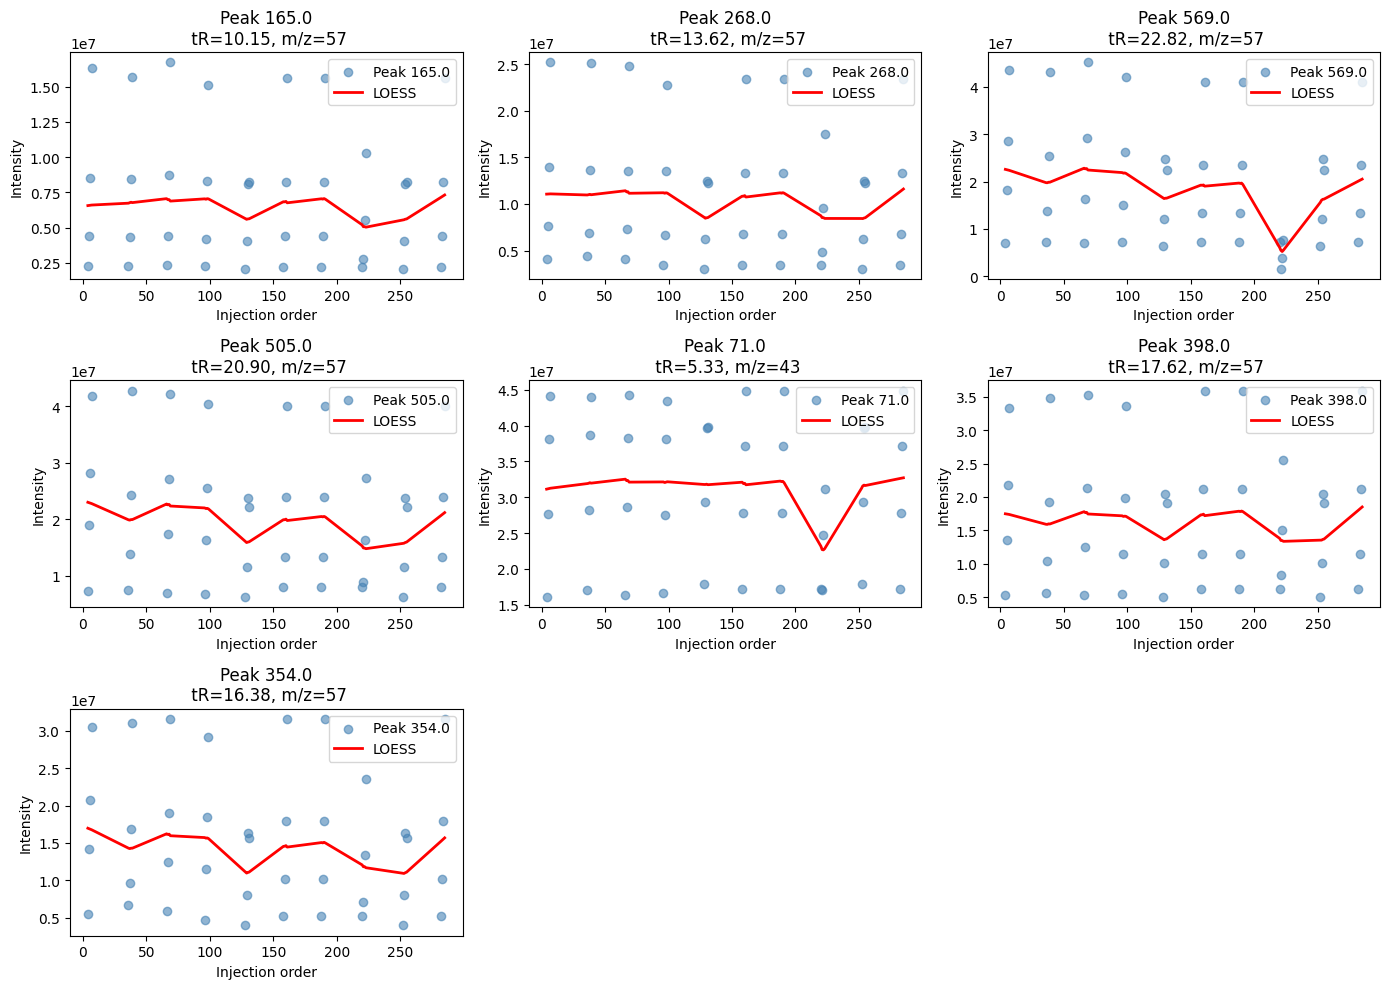

In [ ]:

from statsmodels.nonparametric.smoothers_lowess import lowess

stable_ids = stable_peaks["Peak"].unique()

plt.figure(figsize=(14, 10))

for i, peak in enumerate(stable_ids, 1):
    sub = df_qc[df_qc["Peak"] == peak].dropna(
        subset=["Intensity","Injection_order"]
    )
    if sub.empty:
        continue
    
    x = sub["Injection_order"].values
    y = sub["Intensity"].values
    
    # LOESS smooth for visualization only
    loess_fit = lowess(y, x, frac=0.3, return_sorted=True)
    
    plt.subplot(3, 3, i)
    plt.scatter(x, y, alpha=0.6, label=f"Peak {peak}", color="steelblue")
    plt.plot(loess_fit[:,0], loess_fit[:,1], color="red", linewidth=2, label="LOESS")
    
    plt.title(f"Peak {peak}\n tR={sub['tR_best'].iloc[0]:.2f}, m/z={sub['m/z'].iloc[0]}")
    plt.xlabel("Injection order")
    plt.ylabel("Intensity")
    plt.legend()

plt.tight_layout()
plt.show()


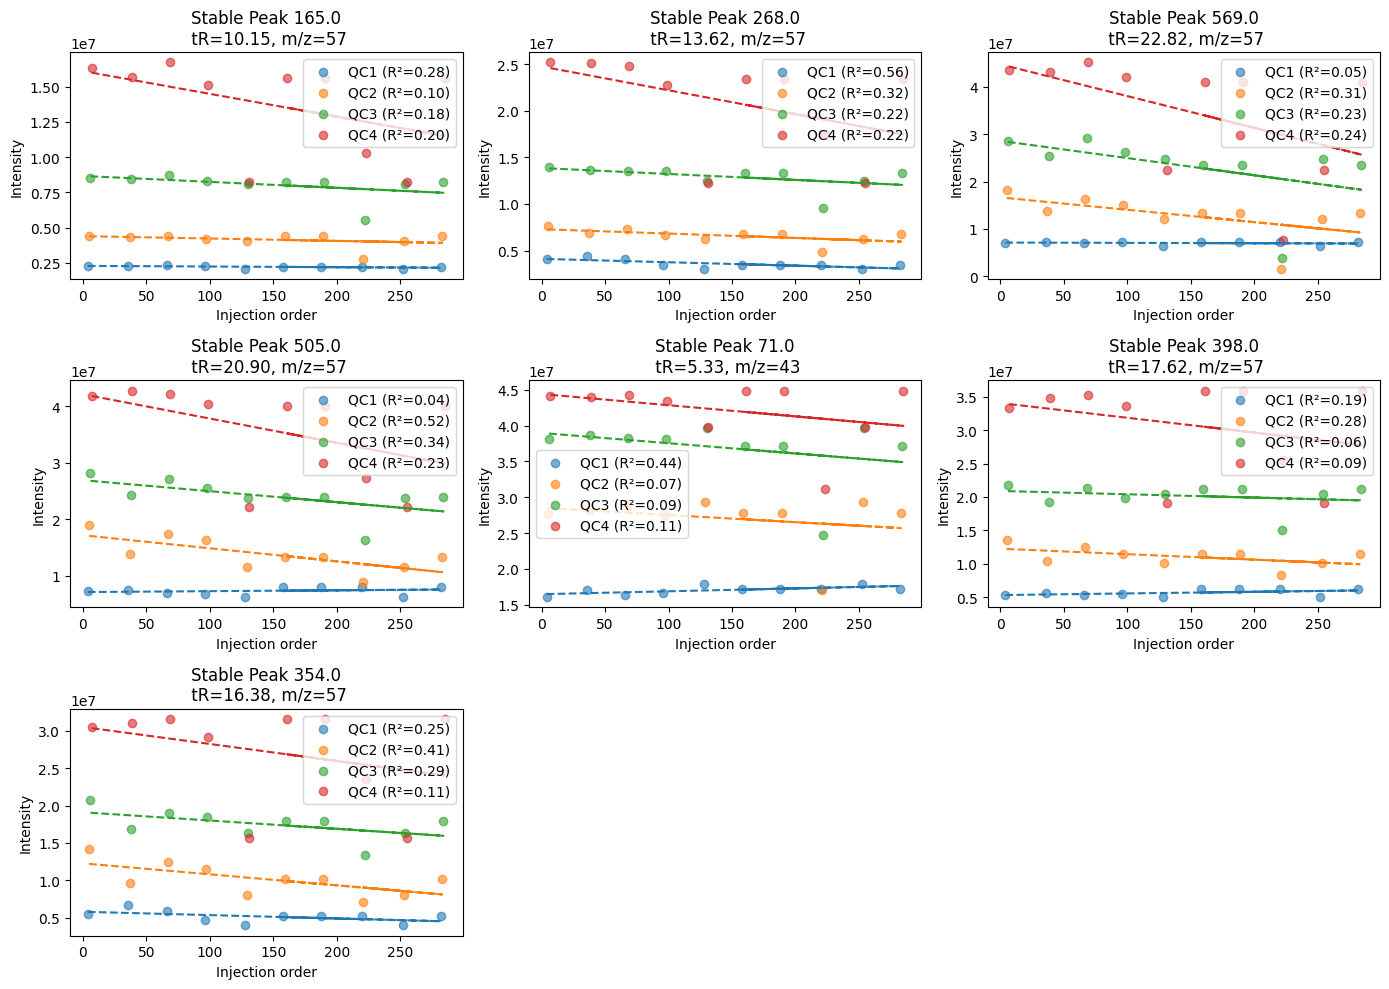

In [ ]:
qc_levels = ["QC1", "QC2", "QC3", "QC4"]

plt.figure(figsize=(14, 10))

for i, peak in enumerate(stable_ids, 1):
    sub = df_qc[df_qc["Peak"] == peak].dropna(
        subset=["Intensity","Injection_order"]
    )
    if sub.empty:
        continue
    
    plt.subplot(3, 3, i)
    
    # Separate by QC level
    for qc in qc_levels:
        sub_qc = sub[sub["Sample"].str.startswith(qc)]
        if sub_qc.empty:
            continue

        x = sub_qc["Injection_order"].values
        y = sub_qc["Intensity"].values
        
        # Linear regression for drift check
        if len(sub_qc) > 1:
            model = LinearRegression().fit(x.reshape(-1,1), y)
            y_pred = model.predict(x.reshape(-1,1))
            r2 = model.score(x.reshape(-1,1), y)
        else:
            y_pred = y
            r2 = np.nan

        plt.scatter(x, y, alpha=0.6, label=f"{qc} (R²={r2:.2f})")
        plt.plot(x, y_pred, linestyle="--")

    plt.title(f"Stable Peak {peak}\n tR={sub['tR_best'].iloc[0]:.2f}, m/z={sub['m/z'].iloc[0]}")
    plt.xlabel("Injection order")
    plt.ylabel("Intensity")
    plt.legend()

plt.tight_layout()
plt.show()


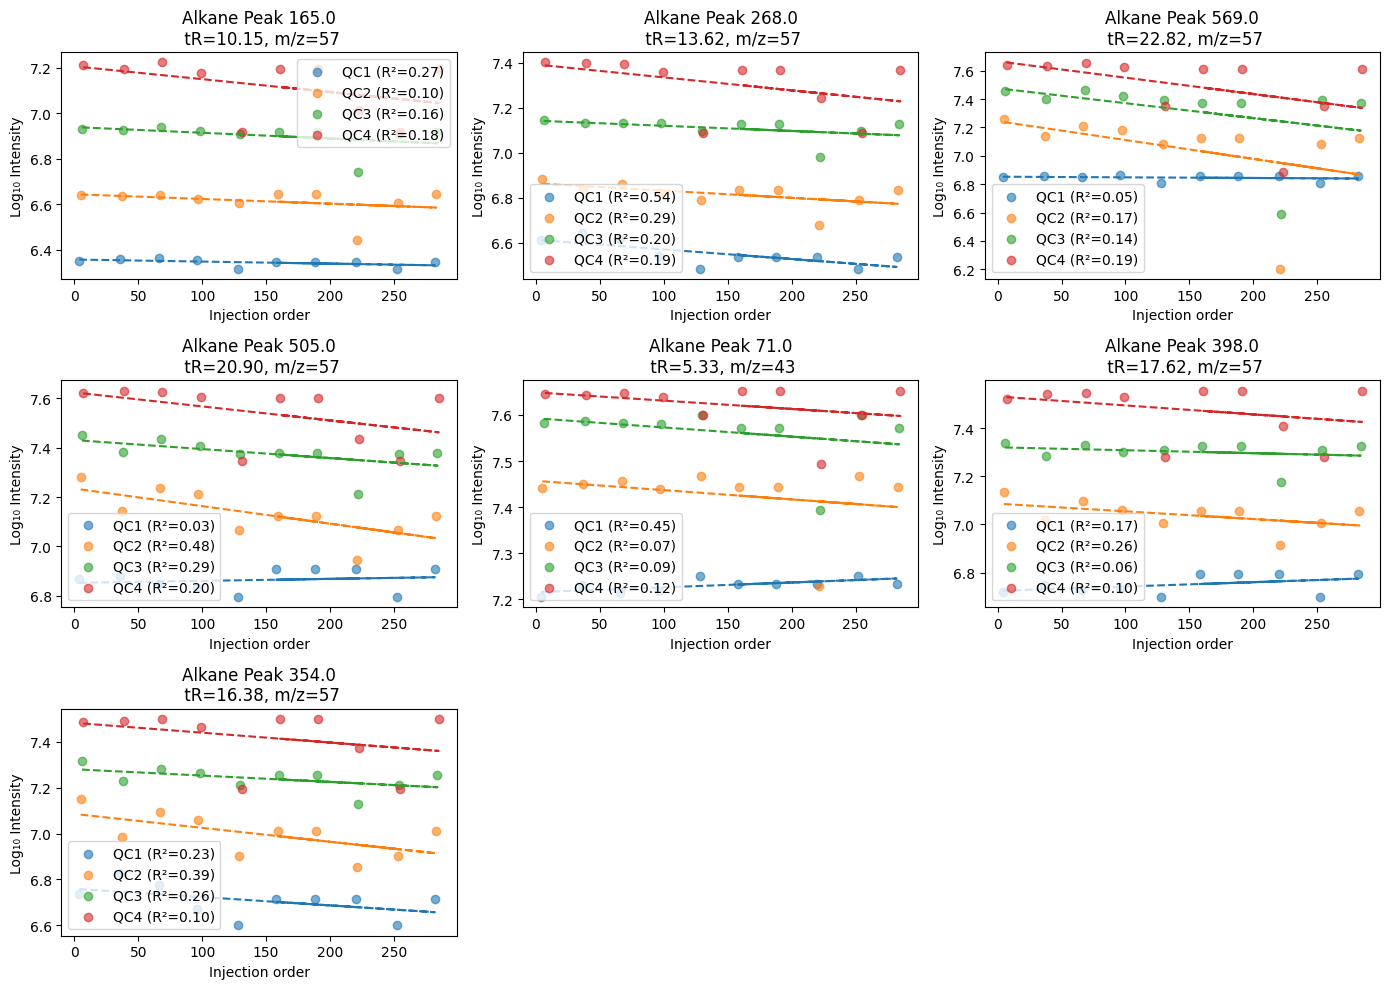

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

qc_levels = ["QC1", "QC2", "QC3", "QC4"]

# Keep only alkane peaks
alkane_ids = stable_peaks["Peak"].unique()
alkan_qc = df_qc[df_qc["Peak"].isin(alkane_ids)].copy()

# Apply log10 transformation to intensity
alkan_qc["Log_Intensity"] = np.log10(alkan_qc["Intensity"] + 1)  # +1 to avoid log(0)

# Plot
plt.figure(figsize=(14, 10))

for i, peak in enumerate(alkane_ids, 1):
    sub = alkan_qc[alkan_qc["Peak"] == peak].dropna(subset=["Log_Intensity","Injection_order"]).copy()
    if sub.empty:
        continue
    
    plt.subplot(3, 3, i)
    
    for qc in qc_levels:
        sub_qc = sub[sub["Sample"].str.startswith(qc)].copy()
        if sub_qc.empty:
            continue

        x = sub_qc["Injection_order"].values
        y = sub_qc["Log_Intensity"].values

        if len(sub_qc) > 1:
            model = LinearRegression().fit(x.reshape(-1,1), y)
            y_pred = model.predict(x.reshape(-1,1))
            r2 = model.score(x.reshape(-1,1), y)
        else:
            y_pred = y
            r2 = np.nan

        plt.scatter(x, y, alpha=0.6, label=f"{qc} (R²={r2:.2f})")
        plt.plot(x, y_pred, linestyle="--")

    plt.title(f"Alkane Peak {peak}\n tR={sub['tR_best'].iloc[0]:.2f}, m/z={sub['m/z'].iloc[0]}")
    plt.xlabel("Injection order")
    plt.ylabel("Log₁₀ Intensity")
    plt.legend()

plt.tight_layout()
plt.show()


    Peak   QC     Slope        R2
0  165.0  QC1 -0.000090  0.272198
1  165.0  QC2 -0.000207  0.098858
2  165.0  QC3 -0.000251  0.163826
3  165.0  QC4 -0.000567  0.181066
4  268.0  QC1 -0.000427  0.542441

Global drift (mean slope across alkanes): -0.0004 log10 intensity per injection


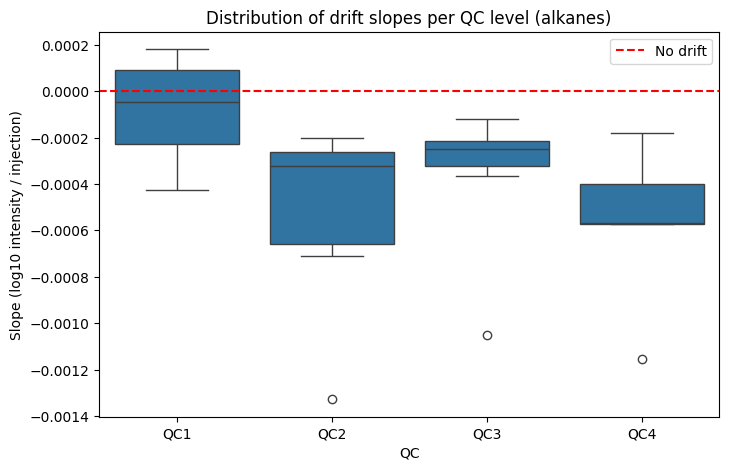

In [ ]:
from sklearn.linear_model import LinearRegression
import seaborn as sns

alkan_qc = alkan_qc.copy()
alkan_qc["QC_label"] = alkan_qc["Sample"].str.extract(r"(QC\d+)")

# Log-transform intensities if not already done
if "Log_Intensity" not in alkan_qc.columns:
    alkan_qc["Log_Intensity"] = np.log10(alkan_qc["Intensity"])

drift_summary = []

for peak in alkane_ids:
    sub = alkan_qc[alkan_qc["Peak"] == peak].copy()
    for qc in qc_levels:
        sub_qc = sub[sub["QC_label"] == qc].dropna(subset=["Log_Intensity","Injection_order"])
        if len(sub_qc) > 1:
            X = sub_qc["Injection_order"].values.reshape(-1, 1)
            y = sub_qc["Log_Intensity"].values
            model = LinearRegression().fit(X, y)
            slope = model.coef_[0]
            r2 = model.score(X, y)
            drift_summary.append((peak, qc, slope, r2))

# Make DataFrame
drift_df = pd.DataFrame(drift_summary, columns=["Peak","QC","Slope","R2"])

print(drift_df.head())

# Average drift across alkanes
mean_slope = drift_df["Slope"].mean()
print(f"\nGlobal drift (mean slope across alkanes): {mean_slope:.4f} log10 intensity per injection")



plt.figure(figsize=(8,5))
sns.boxplot(x="QC", y="Slope", data=drift_df)
plt.axhline(0, color="red", linestyle="--", label="No drift")
plt.title("Distribution of drift slopes per QC level (alkanes)")
plt.ylabel("Slope (log10 intensity / injection)")
plt.legend()
plt.show()


In [ ]:

from statsmodels.nonparametric.smoothers_lowess import lowess
#Estimate drift from alkanes

# Keep only alkane peaks (stable peaks)
alkane_ids = stable_peaks["Peak"].unique()
alkan_qc = df_qc[df_qc["Peak"].isin(alkane_ids)].copy()

# Extract QC label
alkan_qc["QC_label"] = alkan_qc["Sample"].str.extract(r"(QC\d+)")

# Log-transform intensities for stability
alkan_qc["Log_Intensity"] = np.log10(alkan_qc["Intensity"] + 1)

# Fit LOESS on all alkane QC points (global drift)
x = alkan_qc["Injection_order"].values
y = alkan_qc["Log_Intensity"].values
loess_fit = lowess(y, x, frac=0.3, return_sorted=True)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.3, label="Alkane QCs (log-intensity)")
plt.plot(loess_fit[:,0], loess_fit[:,1], color="red", linewidth=2, label="Global drift (LOESS)")
plt.xlabel("Injection order")
plt.ylabel("Log10 Intensity")
plt.title("Global drift estimated from alkane QCs (no concentration)")
plt.legend()
plt.show()




metadata_cols = ['Peak', 'tR_best', 'm/z']
sample_cols = [c for c in selected_data.columns if c not in metadata_cols]

# Rename columns
rename_map_samples = {col: col.split()[-1] for col in sample_cols}
selected_data.rename(columns=rename_map_samples, inplace=True)
sample_cols = [rename_map_samples[c] for c in sample_cols]

# Reshape to long format
long_samples = selected_data.melt(
    id_vars=metadata_cols,
    value_vars=sample_cols,
    var_name="Filename",
    value_name="Intensity"
)

samples_merged = master_table.merge(long_samples, on="Filename", how="inner")
samples_merged['Intensity'] = pd.to_numeric(samples_merged['Intensity'], errors='coerce')
samples_merged = samples_merged.dropna(subset=['Intensity', 'Injection_order'])

print(samples_merged)

#Apply correction (global drift correction)
all_data = pd.concat([samples_merged, df_qc], ignore_index=True)

corrected_records = []
for peak in all_data["Peak"].unique():
    sub = all_data[all_data["Peak"] == peak].copy()

    # Interpolate drift factor (log scale)
    drift_factor = np.interp(sub["Injection_order"], loess_fit[:,0], loess_fit[:,1])
    
    # Correct intensities by subtracting drift (log scale)
    log_intensity = np.log10(sub["Intensity"] + 1)
    log_corrected = log_intensity - (drift_factor - drift_factor.mean())
    sub["Intensity_corrected"] = 10**log_corrected - 1
    
    corrected_records.append(sub)

df_corrected = pd.concat(corrected_records, ignore_index=True)


#Evaluate correction

#  On QCs (R² drift vs injection order) 
qc_eval = []
for peak in df_qc["Peak"].unique():
    raw = df_qc[df_qc["Peak"] == peak]
    corr = df_corrected[(df_corrected["Peak"] == peak) & 
                        (df_corrected["Sample"].str.startswith("QC"))]
    
    if len(raw) > 2 and len(corr) > 2:
        # Before correction
        X_raw = raw["Injection_order"].values.reshape(-1, 1)
        y_raw = np.log10(raw["Intensity"].values + 1)
        r2_raw = LinearRegression().fit(X_raw, y_raw).score(X_raw, y_raw)

        # After correction
        X_corr = corr["Injection_order"].values.reshape(-1, 1)
        y_corr = np.log10(corr["Intensity_corrected"].values + 1)
        r2_corr = LinearRegression().fit(X_corr, y_corr).score(X_corr, y_corr)

        qc_eval.append((peak, r2_raw, r2_corr))

qc_eval_df = pd.DataFrame(qc_eval, columns=["Peak", "R2_before", "R2_after"])

plt.figure(figsize=(6,6))
plt.scatter(qc_eval_df["R2_before"], qc_eval_df["R2_after"], alpha=0.7)
plt.plot([0,1],[0,1],"r--",label="y=x (no change)")
plt.xlabel("R² before correction")
plt.ylabel("R² after correction")
plt.title("QC drift correction evaluation (alkanes)")
plt.legend()
plt.show()


#  On Samples (variance reduction)
sample_eval = []
for peak in samples_merged["Peak"].unique():
    raw = samples_merged[samples_merged["Peak"] == peak]["Intensity"]
    corr = df_corrected[(df_corrected["Peak"] == peak) & 
                        (~df_corrected["Sample"].str.startswith("QC"))]["Intensity_corrected"]
    
    if len(raw) > 2 and len(corr) > 2:
        var_before = np.var(np.log10(raw.values + 1))
        var_after = np.var(np.log10(corr.values + 1))
        sample_eval.append((peak, var_before, var_after))

sample_eval_df = pd.DataFrame(sample_eval, columns=["Peak","Var_before","Var_after"])

plt.figure(figsize=(7,5))
sns.boxplot(data=pd.melt(sample_eval_df[["Var_before","Var_after"]], 
                         var_name="Stage", value_name="Variance"),
            x="Stage", y="Variance")
plt.title("Sample variance reduction (alkane-based correction)")
plt.show()


NameError: name 'stable_peaks' is not defined

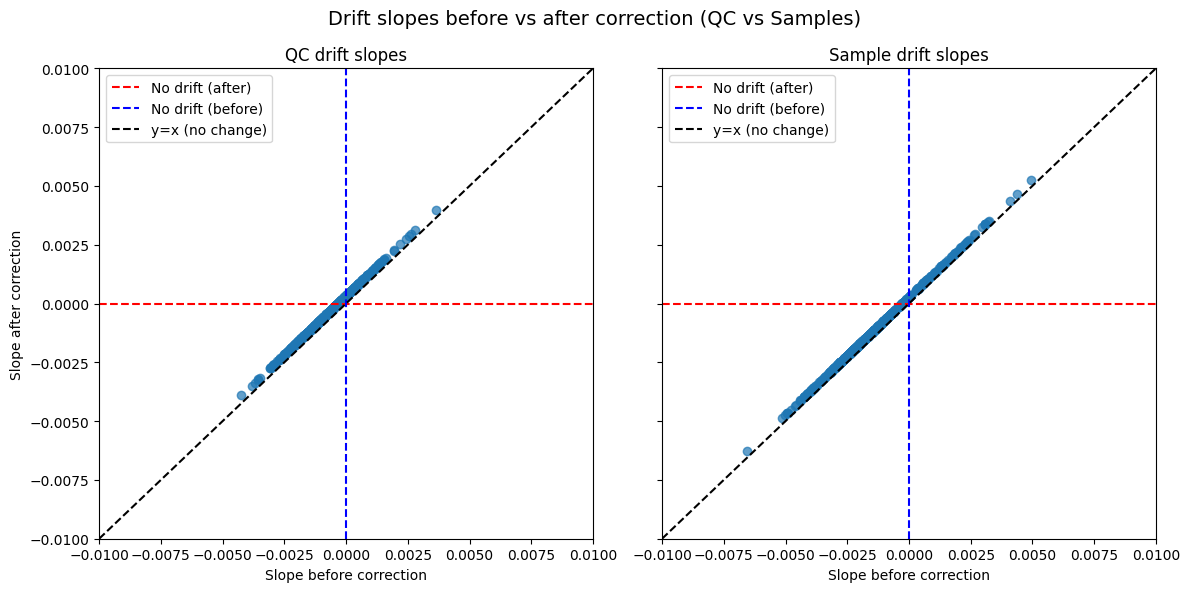

In [ ]:


#  Slopes for QCs 
qc_slopes = []
for peak in df_qc["Peak"].unique():
    raw = df_qc[df_qc["Peak"] == peak]
    corr = df_corrected[(df_corrected["Peak"] == peak) & 
                        (df_corrected["Sample"].str.startswith("QC"))]
    
    if len(raw) > 2 and len(corr) > 2:
        # Before correction
        X_raw = raw["Injection_order"].values.reshape(-1, 1)
        y_raw = np.log10(raw["Intensity"].values + 1)
        slope_raw = LinearRegression().fit(X_raw, y_raw).coef_[0]

        # After correction
        X_corr = corr["Injection_order"].values.reshape(-1, 1)
        y_corr = np.log10(corr["Intensity_corrected"].values + 1)
        slope_corr = LinearRegression().fit(X_corr, y_corr).coef_[0]

        qc_slopes.append((peak, slope_raw, slope_corr))

qc_slopes_df = pd.DataFrame(qc_slopes, columns=["Peak","Slope_before","Slope_after"])

#  Slopes for Samples 
sample_slopes = []
for peak in samples_merged["Peak"].unique():
    raw = samples_merged[samples_merged["Peak"] == peak]
    corr = df_corrected[(df_corrected["Peak"] == peak) & 
                        (~df_corrected["Sample"].str.startswith("QC"))]
    
    if len(raw) > 2 and len(corr) > 2:
        # Before correction
        X_raw = raw["Injection_order"].values.reshape(-1, 1)
        y_raw = np.log10(raw["Intensity"].values + 1)
        slope_raw = LinearRegression().fit(X_raw, y_raw).coef_[0]

        # After correction
        X_corr = corr["Injection_order"].values.reshape(-1, 1)
        y_corr = np.log10(corr["Intensity_corrected"].values + 1)
        slope_corr = LinearRegression().fit(X_corr, y_corr).coef_[0]

        sample_slopes.append((peak, slope_raw, slope_corr))

sample_slopes_df = pd.DataFrame(sample_slopes, columns=["Peak","Slope_before","Slope_after"])

fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex=True, sharey=True)

# QC plot
axes[0].scatter(qc_slopes_df["Slope_before"], qc_slopes_df["Slope_after"], alpha=0.7)
axes[0].axhline(0, color="red", linestyle="--", label="No drift (after)")
axes[0].axvline(0, color="blue", linestyle="--", label="No drift (before)")
axes[0].plot([-0.01,0.01],[-0.01,0.01],"k--",label="y=x (no change)")
axes[0].set_title("QC drift slopes")
axes[0].set_xlabel("Slope before correction")
axes[0].set_ylabel("Slope after correction")

# Sample plot
axes[1].scatter(sample_slopes_df["Slope_before"], sample_slopes_df["Slope_after"], alpha=0.7)
axes[1].axhline(0, color="red", linestyle="--", label="No drift (after)")
axes[1].axvline(0, color="blue", linestyle="--", label="No drift (before)")
axes[1].plot([-0.01,0.01],[-0.01,0.01],"k--",label="y=x (no change)")
axes[1].set_title("Sample drift slopes")
axes[1].set_xlabel("Slope before correction")


for ax in axes:
    ax.set_xlim(-0.01,0.01)
    ax.set_ylim(-0.01,0.01)
    ax.legend()

plt.suptitle("Drift slopes before vs after correction (QC vs Samples)", fontsize=14)
plt.tight_layout()
plt.show()

plt.show()


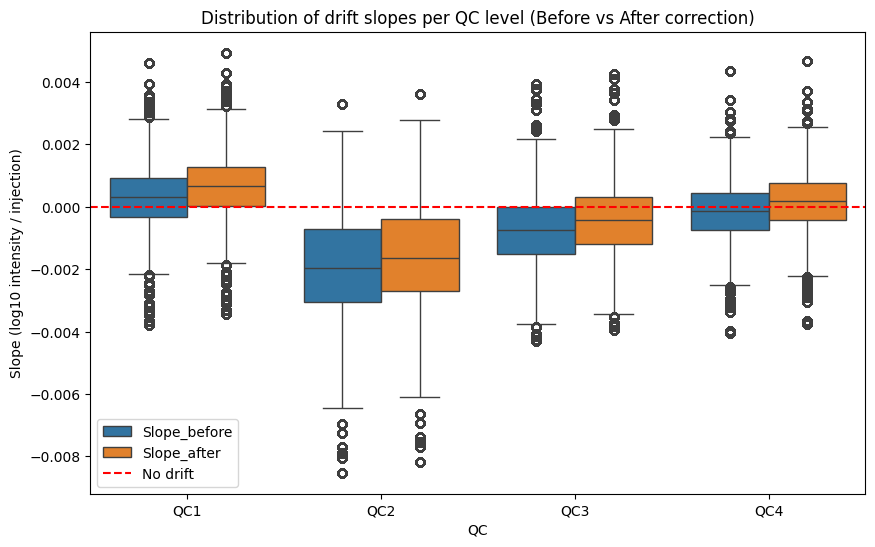

In [ ]:


#  Calculate slopes before correction
slopes_before = []
for peak in df_qc["Peak"].unique():
    sub = df_qc[df_qc["Peak"] == peak].copy()
    sub["QC_label"] = sub["Sample"].str.extract(r"(QC\d+)")
    
    for qc in sub["QC_label"].dropna().unique():
        sub_qc = sub[sub["QC_label"] == qc]
        if len(sub_qc) > 2:
            X = sub_qc["Injection_order"].values.reshape(-1,1)
            y = np.log10(sub_qc["Intensity"].values + 1)
            model = LinearRegression().fit(X,y)
            slope = model.coef_[0]
            slopes_before.append((qc, slope))

slopes_before_df = pd.DataFrame(slopes_before, columns=["QC","Slope_before"])

#  Calculate slopes after correction 
slopes_after = []
for peak in df_corrected["Peak"].unique():
    sub = df_corrected[df_corrected["Peak"] == peak].copy()
    sub["QC_label"] = sub["Sample"].str.extract(r"(QC\d+)")
    
    for qc in sub["QC_label"].dropna().unique():
        sub_qc = sub[sub["QC_label"] == qc]
        if len(sub_qc) > 2:
            X = sub_qc["Injection_order"].values.reshape(-1,1)
            y = np.log10(sub_qc["Intensity_corrected"].values + 1)
            model = LinearRegression().fit(X,y)
            slope = model.coef_[0]
            slopes_after.append((qc, slope))

slopes_after_df = pd.DataFrame(slopes_after, columns=["QC","Slope_after"])

#  Merge before/after 
slopes_df = pd.merge(slopes_before_df, slopes_after_df, on="QC")
slopes_melt = pd.melt(slopes_df, id_vars="QC", 
                      value_vars=["Slope_before","Slope_after"],
                      var_name="Stage", value_name="Slope")

plt.figure(figsize=(10,6))
sns.boxplot(data=slopes_melt, x="QC", y="Slope", hue="Stage")
plt.axhline(0, color="red", linestyle="--", label="No drift")
plt.title("Distribution of drift slopes per QC level (Before vs After correction)")
plt.ylabel("Slope (log10 intensity / injection)")
plt.legend()
plt.show()


# Parameter grid search for LOESS correction

In [ ]:

frac_values = [0.2, 0.3, 0.4]
alpha_values = [0.01, 0.05, 0.1]   
delta_values = [0.0, 1.0, 5.0]

# Store evaluation results
results = []

# Use only QC alkanes to fit drift
alkan_qc = df_qc[df_qc["Peak"].isin(stable_peaks["Peak"].unique())].copy()
alkan_qc["Log_Intensity"] = np.log10(alkan_qc["Intensity"] + 1)


# Grid search over parameters

for frac in frac_values:
    for alpha in alpha_values:  
        for delta in delta_values:

            # Fit LOESS on alkanes 
            smoothed = lowess(
                endog=alkan_qc["Log_Intensity"],
                exog=alkan_qc["Injection_order"],
                frac=frac,
                delta=delta,
                return_sorted=False
            )

            # Apply correction to full dataset
            df_tmp = df_qc.copy()
            df_tmp["Log_Intensity"] = np.log10(df_tmp["Intensity"] + 1)
            df_tmp["Drift"] = np.interp(df_tmp["Injection_order"],
                                        alkan_qc["Injection_order"],
                                        smoothed)
            df_tmp["Corrected"] = df_tmp["Log_Intensity"] - df_tmp["Drift"]

            #  Evaluate on QC slopes 
            improvements = []
            for peak in df_tmp["Peak"].unique():
                sub = df_tmp[df_tmp["Peak"] == peak]
                if len(sub) < 5:
                    continue

                # Before correction
                X_raw = sub["Injection_order"].values.reshape(-1, 1)
                y_raw = sub["Log_Intensity"].values
                r2_before = LinearRegression().fit(X_raw, y_raw).score(X_raw, y_raw)

                # After correction
                y_corr = sub["Corrected"].values
                r2_after = LinearRegression().fit(X_raw, y_corr).score(X_raw, y_corr)

                improvements.append(r2_before - r2_after)

            if len(improvements) > 0:
                mean_improvement = np.mean(improvements)
                results.append((frac, alpha, delta, mean_improvement))


opt_df= pd.DataFrame(results, columns=["frac", "alpha", "delta", "mean_improvement"])

# Best parameters
best_params = opt_df.loc[opt_df["mean_improvement"].idxmax()]

print("Best parameters:")
print(best_params)


# Plot heatmap (frac vs delta, averaged over alpha)

heatmap_df =  opt_df.groupby(["frac", "delta"])["mean_improvement"].mean().unstack()

plt.figure(figsize=(7,5))
sns.heatmap(heatmap_df, annot=True, cmap="coolwarm", center=0)
plt.title("Mean QC drift improvement across parameters")
plt.ylabel("frac")
plt.xlabel("delta")
plt.show()


KeyboardInterrupt: 

 # Apply LOESS correction with best parameters

 Drift correction applied using QC alkanes (frac=0.4, delta=0.0).
        #         Filename                            Sample  Block  Plot  \
0  1152.0  S96_44_B1_D1_T1     NLD;MET;96;64;2024;44;FELSINA    1.0   1.0   
1  1153.0  S96_14_B1_D1_T1      NLD;MET;96;64;2024;14;AVARNA    1.0   2.0   
2  1154.0  S96_83_B1_D1_T1  NLD;MET;96;64;2024;83;SARPO MIRA    1.0   3.0   
3  1155.0   S96_9_B1_D1_T1         NLD;MET;96;64;2024;9;ANTI    1.0   4.0   
4  1156.0  S96_28_B1_D1_T1      NLD;MET;96;64;2024;28;CHOPIN    1.0   5.0   

   Sample_order  Sample_date  Rep  Day  Injection_order  ...  Tenax  Remark  \
0           1.0          NaN  1.0    1               10  ...    NaN     NaN   
1           2.0          NaN  1.0    1               11  ...    NaN     NaN   
2           3.0          NaN  1.0    1               12  ...    NaN     NaN   
3           4.0          NaN  1.0    1               13  ...    NaN     NaN   
4           5.0          NaN  1.0    1               14  ...    NaN     NaN 

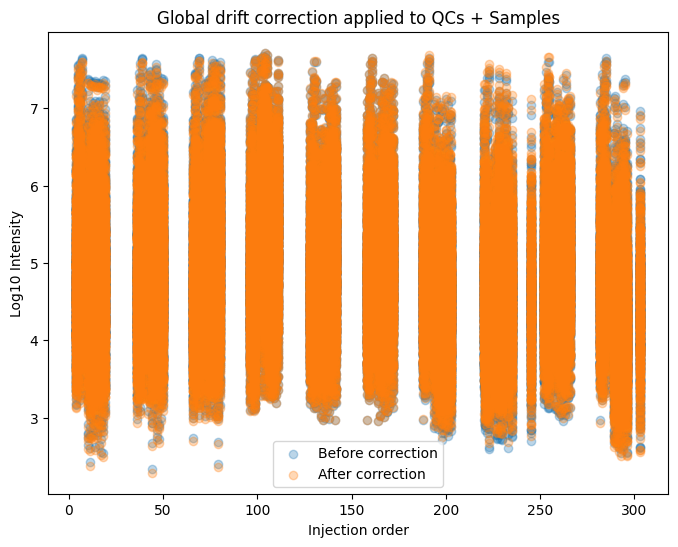

In [ ]:


# Fit drift using QC alkanes only

# Take only the stable alkane peaks from QCs
alkan_qc = df_qc[df_qc["Peak"].isin(stable_peaks["Peak"].unique())].copy()
alkan_qc["Log_Intensity"] = np.log10(alkan_qc["Intensity"] + 1)

# Apply LOESS smoothing (best parameters found earlier)
best_frac = 0.4
best_delta = 0.0
best_alpha=0.01
loess_fit = lowess(
    endog=alkan_qc["Log_Intensity"],
    exog=alkan_qc["Injection_order"],
    frac=best_frac,
    delta=best_delta,
    return_sorted=True
)


#Apply correction to ALL data (samples + QCs)


all_data = pd.concat([samples_merged, df_qc], ignore_index=True)

corrected_records = []
for peak in all_data["Peak"].unique():
    sub = all_data[all_data["Peak"] == peak].copy()

    # Interpolate drift factor for each injection order
    drift_factor = np.interp(sub["Injection_order"], loess_fit[:, 0], loess_fit[:, 1])

    # Apply correction on log scale
    log_intensity = np.log10(sub["Intensity"] + 1)
    log_corrected = log_intensity - (drift_factor - drift_factor.mean())

    # Back-transform to intensity scale
    sub["Intensity_corrected"] = 10**log_corrected - 1

    corrected_records.append(sub)

df_corrected = pd.concat(corrected_records, ignore_index=True)

print(" Drift correction applied using QC alkanes (frac=0.4, delta=0.0).")
print(df_corrected.head())


#  Quick visualization


plt.figure(figsize=(8,6))
plt.scatter(all_data["Injection_order"], np.log10(all_data["Intensity"]+1), 
            alpha=0.3, label="Before correction")
plt.scatter(df_corrected["Injection_order"], np.log10(df_corrected["Intensity_corrected"]+1), 
            alpha=0.3, label="After correction")
plt.xlabel("Injection order")
plt.ylabel("Log10 Intensity")
plt.title("Global drift correction applied to QCs + Samples")
plt.legend()
plt.show()


# Rank QCs on corrected data

In [ ]:


# Extract only QC rows from corrected data
qc_corrected = df_corrected[df_corrected["Sample"].str.startswith("QC")].copy()

# Compute QC statistics
qc_stats = qc_corrected.groupby("Sample").agg(
    Median_intensity=("Intensity_corrected", "median"),
    CV=("Intensity_corrected", lambda x: np.std(x) / np.mean(x) if np.mean(x) > 0 else np.nan),
    Completeness=("Intensity_corrected", lambda x: x.notna().mean())
).reset_index()

# Compute score = -CV * log(Median_intensity) 
qc_stats["Score"] = qc_stats["Median_intensity"].apply(np.log1p) / qc_stats["CV"]

qc_stats["Rank"] = qc_stats["Score"].rank(ascending=False).astype(int)

print(qc_stats.sort_values("Rank"))


  Sample  Median_intensity        CV  Completeness     Score  Rank
0    QC1      56087.721076  3.421426           1.0  3.195945     1
1    QC2      71138.425834  3.633429           1.0  3.074890     2
2    QC3      80873.371975  4.055732           1.0  2.786341     3
3    QC4      63941.712654  5.084025           1.0  2.176571     4


QC1 ranks best: relatively stable (lowest CV ~3.4) even though its median intensity is lowest.

# normalization

In [ ]:
df_corrected

,#,Filename,Sample,Block,Plot,Sample_order,Sample_date,Rep,Day,Injection_order,...,Tenax,Remark,Scan tenax,Check,Peak,tR_best,m/z,Intensity,SampleCol,Intensity_corrected
0,1152.0,S96_44_B1_D1_T1,NLD;MET;96;64;2024;44;FELSINA,1.0,1.0,1.0,NaN,1.0,1,10,...,NaN,NaN,NaN,NaN,1,1.906,40,10596,NaN,9561.412173
1,1153.0,S96_14_B1_D1_T1,NLD;MET;96;64;2024;14;AVARNA,1.0,2.0,2.0,NaN,1.0,1,11,...,NaN,NaN,NaN,NaN,1,1.906,40,20120,NaN,18152.056716
2,1154.0,S96_83_B1_D1_T1,NLD;MET;96;64;2024;83;SARPO MIRA,1.0,3.0,3.0,NaN,1.0,1,12,...,NaN,NaN,NaN,NaN,1,1.906,40,18984,NaN,17123.838459
3,1155.0,S96_9_B1_D1_T1,NLD;MET;96;64;2024;9;ANTI,1.0,4.0,4.0,NaN,1.0,1,13,...,NaN,NaN,NaN,NaN,1,1.906,40,16056,NaN,14479.913782
4,1156.0,S96_28_B1_D1_T1,NLD;MET;96;64;2024;28;CHOPIN,1.0,5.0,5.0,NaN,1.0,1,14,...,NaN,NaN,NaN,NaN,1,1.906,40,19568,NaN,17643.764736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80143,1435.0,S96_69_B1_D10_T1,NLD;MET;96;64;2024;69;OSPREY,10.0,6.0,91.0,NaN,1.0,10,293,...,NaN,NaN,NaN,NaN,602,23.412,220,55996,NaN,50766.779241
80144,1436.0,S96_84_B1_D10_T1,NLD;MET;96;64;2024;84;SMART,10.0,7.0,92.0,NaN,1.0,10,294,...,NaN,NaN,NaN,NaN,602,23.412,220,21014,NaN,19051.536399
80145,1437.0,S96_91_B1_D10_T1,NLD;MET;96;64;2024;91;TRIPLE7,10.0,8.0,93.0,NaN,1.0,10,295,...,NaN,NaN,NaN,NaN,602,23.412,220,13845,NaN,12552.005900
80146,1438.0,S96_19_B1_D10_T1,NLD;MET;96;64;2024;19;BINTJE,10.0,10.0,94.0,NaN,1.0,10,296,...,NaN,NaN,NaN,NaN,602,23.412,220,33503,NaN,30374.264312


In [ ]:
#  Separate QCs and Samples 
qcs = df_corrected[df_corrected["Sample"].str.startswith("QC")].copy()
samples = df_corrected[~df_corrected["Sample"].str.startswith("QC")].copy()

#  Compute reference from QC1 (median intensity per peak) 
qc1_ref = (
    qcs[qcs["Sample"].str.startswith("QC1")]
    .groupby("Peak")["Intensity_corrected"]
    .median()
    .rename("QC1_median")
)

#  Merge QC1 reference into samples 
samples = samples.merge(qc1_ref, on="Peak", how="left")

print(samples)
# Normalize using QC1 reference
samples["Ratio_normalized"] = samples["Intensity_corrected"] / samples["QC1_median"]

# Log10 transform 
samples["Log10_normalized"] = np.log10(samples["Ratio_normalized"] + 1)

print(samples[["Peak", "Intensity_corrected", "QC1_median", 
               "Ratio_normalized", "Log10_normalized"]].head())
samples

            #          Filename                            Sample  Block  \
0      1152.0   S96_44_B1_D1_T1     NLD;MET;96;64;2024;44;FELSINA    1.0   
1      1153.0   S96_14_B1_D1_T1      NLD;MET;96;64;2024;14;AVARNA    1.0   
2      1154.0   S96_83_B1_D1_T1  NLD;MET;96;64;2024;83;SARPO MIRA    1.0   
3      1155.0    S96_9_B1_D1_T1         NLD;MET;96;64;2024;9;ANTI    1.0   
4      1156.0   S96_28_B1_D1_T1      NLD;MET;96;64;2024;28;CHOPIN    1.0   
...       ...               ...                               ...    ...   
56583  1435.0  S96_69_B1_D10_T1      NLD;MET;96;64;2024;69;OSPREY   10.0   
56584  1436.0  S96_84_B1_D10_T1       NLD;MET;96;64;2024;84;SMART   10.0   
56585  1437.0  S96_91_B1_D10_T1     NLD;MET;96;64;2024;91;TRIPLE7   10.0   
56586  1438.0  S96_19_B1_D10_T1      NLD;MET;96;64;2024;19;BINTJE   10.0   
56587  1445.0  S96_46_B1_D10_T2     NLD;MET;96;64;2024;46;FESTIEN   10.0   

       Plot  Sample_order  Sample_date  Rep  Day  Injection_order  ...  \
0       1.0  

,#,Filename,Sample,Block,Plot,Sample_order,Sample_date,Rep,Day,Injection_order,...,Check,Peak,tR_best,m/z,Intensity,SampleCol,Intensity_corrected,QC1_median,Ratio_normalized,Log10_normalized
0,1152.0,S96_44_B1_D1_T1,NLD;MET;96;64;2024;44;FELSINA,1.0,1.0,1.0,NaN,1.0,1,10,...,NaN,1,1.906,40,10596,NaN,9561.412173,46495.044729,0.205644,0.081219
1,1153.0,S96_14_B1_D1_T1,NLD;MET;96;64;2024;14;AVARNA,1.0,2.0,2.0,NaN,1.0,1,11,...,NaN,1,1.906,40,20120,NaN,18152.056716,46495.044729,0.390408,0.143142
2,1154.0,S96_83_B1_D1_T1,NLD;MET;96;64;2024;83;SARPO MIRA,1.0,3.0,3.0,NaN,1.0,1,12,...,NaN,1,1.906,40,18984,NaN,17123.838459,46495.044729,0.368294,0.136179
3,1155.0,S96_9_B1_D1_T1,NLD;MET;96;64;2024;9;ANTI,1.0,4.0,4.0,NaN,1.0,1,13,...,NaN,1,1.906,40,16056,NaN,14479.913782,46495.044729,0.311429,0.117745
4,1156.0,S96_28_B1_D1_T1,NLD;MET;96;64;2024;28;CHOPIN,1.0,5.0,5.0,NaN,1.0,1,14,...,NaN,1,1.906,40,19568,NaN,17643.764736,46495.044729,0.379476,0.139714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56583,1435.0,S96_69_B1_D10_T1,NLD;MET;96;64;2024;69;OSPREY,10.0,6.0,91.0,NaN,1.0,10,293,...,NaN,602,23.412,220,55996,NaN,50766.779241,NaN,NaN,NaN
56584,1436.0,S96_84_B1_D10_T1,NLD;MET;96;64;2024;84;SMART,10.0,7.0,92.0,NaN,1.0,10,294,...,NaN,602,23.412,220,21014,NaN,19051.536399,NaN,NaN,NaN
56585,1437.0,S96_91_B1_D10_T1,NLD;MET;96;64;2024;91;TRIPLE7,10.0,8.0,93.0,NaN,1.0,10,295,...,NaN,602,23.412,220,13845,NaN,12552.005900,NaN,NaN,NaN
56586,1438.0,S96_19_B1_D10_T1,NLD;MET;96;64;2024;19;BINTJE,10.0,10.0,94.0,NaN,1.0,10,296,...,NaN,602,23.412,220,33503,NaN,30374.264312,NaN,NaN,NaN


In [ ]:
# Extract Variety from the Sample column (last part after the last semicolon)
samples["Variety"] = samples["Sample"].str.split(";").str[-1]

# Keep only the relevant columns
samples_filtered = samples[
    ["Filename", "Sample","Peak", "Variety", "tR_best", "m/z", 
     "Intensity_corrected", "Ratio_normalized", "Log10_normalized"]
].copy()

print(samples_filtered.head())
samples_filtered.to_csv("samples_filtered.csv", index=False)


          Filename                            Sample  Peak     Variety  \
0  S96_44_B1_D1_T1     NLD;MET;96;64;2024;44;FELSINA     1     FELSINA   
1  S96_14_B1_D1_T1      NLD;MET;96;64;2024;14;AVARNA     1      AVARNA   
2  S96_83_B1_D1_T1  NLD;MET;96;64;2024;83;SARPO MIRA     1  SARPO MIRA   
3   S96_9_B1_D1_T1         NLD;MET;96;64;2024;9;ANTI     1        ANTI   
4  S96_28_B1_D1_T1      NLD;MET;96;64;2024;28;CHOPIN     1      CHOPIN   

   tR_best  m/z  Intensity_corrected  Ratio_normalized  Log10_normalized  
0    1.906   40          9561.412173          0.205644          0.081219  
1    1.906   40         18152.056716          0.390408          0.143142  
2    1.906   40         17123.838459          0.368294          0.136179  
3    1.906   40         14479.913782          0.311429          0.117745  
4    1.906   40         17643.764736          0.379476          0.139714  


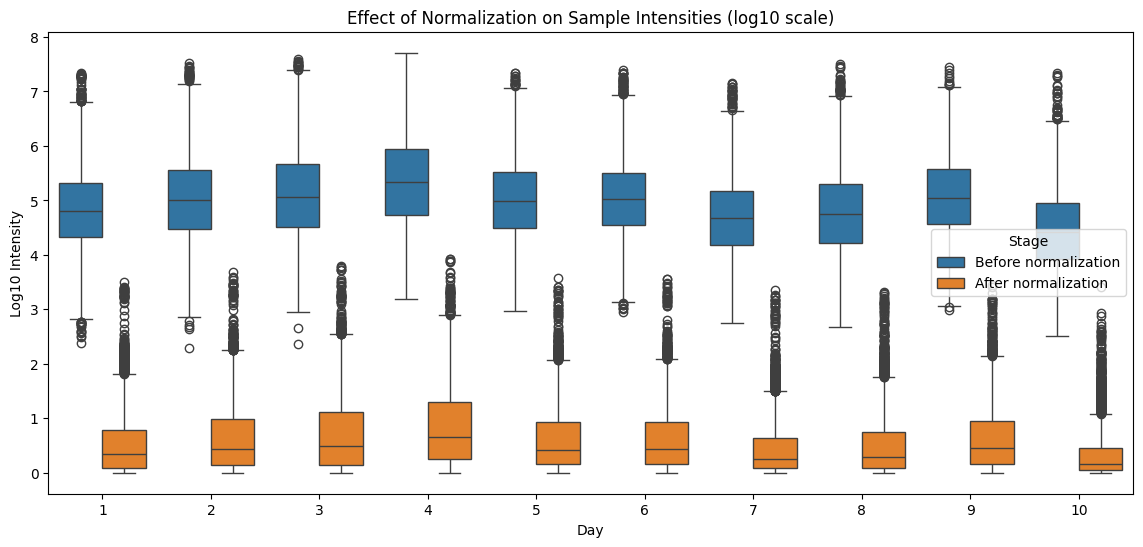

In [ ]:

samples_plot = samples.copy()


samples_plot["Log10_before"] = np.log10(samples_plot["Intensity_corrected"] + 1)
samples_plot["Log10_after"] = np.log10(samples_plot["Ratio_normalized"] + 1)


plot_df = samples_plot.melt(
    id_vars="Day",
    value_vars=["Log10_before", "Log10_after"],
    var_name="Stage",
    value_name="Log10 Intensity"
)


plot_df["Stage"] = plot_df["Stage"].map({
    "Log10_before": "Before normalization",
    "Log10_after": "After normalization"
})


plt.figure(figsize=(14,6))
sns.boxplot(data=plot_df, x="Day", y="Log10 Intensity", hue="Stage")
plt.title("Effect of Normalization on Sample Intensities (log10 scale)")
plt.ylabel("Log10 Intensity")
plt.xlabel("Day")
plt.legend(title="Stage")
plt.show()


# map varaiety names on samples 

In [ ]:
sample_info = samples[["Filename", "Sample"]].drop_duplicates()
sample_info["Variety"] = sample_info["Sample"].str.split(";").str[-1]  # last token

# Keep only one Variety column
samples_with_variety = samples_with_variety.rename(
    columns={"Variety_x": "Variety"}
).drop(columns=["Variety_y"], errors="ignore")

print(samples_with_variety.columns)



Index(['#', 'Filename', 'Sample', 'Block', 'Plot', 'Sample_order',
       'Sample_date', 'Rep', 'Day', 'Injection_order', 'Blender', 'Tenax',
       'Remark', 'Scan tenax', 'Check', 'Peak', 'tR_best', 'm/z', 'Intensity',
       'SampleCol', 'Intensity_corrected', 'QC1_median', 'Ratio_normalized',
       'Log10_normalized', 'Variety'],
      dtype='object')


# unsupervised methods : PCA, HCA


# PCA

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
!pip install adjustText


# Pivot to wide matrix (samples × peaks)
X = samples_with_variety.pivot_table(
    index="Filename",
    columns="Peak",
    values="Log10_normalized",   # or Intensity_corrected if you prefer
    aggfunc="mean"
)

# Impute missing values + scale
imputer = SimpleImputer(strategy="mean")
X_filled = imputer.fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_filled)

# PCA with 2 components
pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)

# Add back metadata
scores_df = pd.DataFrame(scores, index=X.index, columns=["PC1", "PC2"])
scores_df = scores_df.reset_index().merge(
    samples_with_variety[["Filename", "Variety"]].drop_duplicates(),
    on="Filename", how="left"
)




# Select top features (peaks) again
from adjustText import adjust_text

# Get PCA loadings
loadings = pca.components_.T[:, :2]
loading_df = pd.DataFrame(loadings, columns=["PC1", "PC2"], index=X.columns)

# Pick top 5 peaks by absolute PC1/PC2 contribution
loading_df["abs_contrib"] = (loading_df["PC1"]**2 + loading_df["PC2"]**2)**0.5
top_loadings = loading_df.nlargest(5, "abs_contrib")

import plotly.graph_objects as go
import plotly.express as px

# Interactive scatter for samples
fig = px.scatter(
    scores_df,
    x="PC1", y="PC2",
    color="Variety",
    hover_data=["Filename", "Variety"],
    labels={
        "PC1": f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)",
        "PC2": f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)"
    },
    title="Interactive PCA Biplot: Samples + Top 5 Loadings"
)

# Add loadings as arrows
scale = 20  # scaling factor for visibility
for i, row in top_loadings.iterrows():
    fig.add_trace(go.Scatter(
        x=[0, row["PC1"]*scale],
        y=[0, row["PC2"]*scale],
        mode="lines+markers+text",
        line=dict(color="red", width=2),
        marker=dict(size=7, color="red"),
        text=[None, str(i)],  # label only at arrow head
        textposition="top center",
        name=f"Loading: {i}",
        hovertext=f"Peak: {i}<br>PC1: {row['PC1']:.3f}<br>PC2: {row['PC2']:.3f}"
    ))

# Add axis lines
fig.add_shape(type="line", x0=min(scores_df["PC1"]), x1=max(scores_df["PC1"]), y0=0, y1=0,
              line=dict(color="gray", dash="dash"))
fig.add_shape(type="line", x0=0, x1=0, y0=min(scores_df["PC2"]), y1=max(scores_df["PC2"]),
              line=dict(color="gray", dash="dash"))

# Resize for better readability
fig.update_layout(
    width=900, height=900,
    legend=dict(itemsizing="constant", title="Varieties")
)

fig.show()



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# HCA (Hierarchical Cluster Analysis)


First few assignments:
            Filename  Cluster    Variety
0    S96_10_B1_D2_T1        4    ARDECHE
1   S96_11_B1_D10_T1        3      ARGOS
2    S96_12_B1_D5_T1        5    ARIZONA
3    S96_13_B1_D9_T1        5   ATLANTIC
4    S96_14_B1_D1_T1        4     AVARNA
5    S96_15_B1_D6_T1        5    AVENGER
6    S96_16_B1_D3_T1        4     BARAKA
7    S96_17_B1_D9_T1        5     BERBER
8    S96_18_B1_D4_T1        5  BILDTSTAR
9   S96_19_B1_D10_T1        3     BINTJE
10    S96_1_B1_D5_T1        5      ADORA
11   S96_20_B1_D9_T1        5  BLUE STAR
12   S96_21_B1_D1_T1        4      CAMEL
13   S96_22_B1_D8_T1        5    CARDYMA
14   S96_23_B1_D9_T1        5    CARLITA


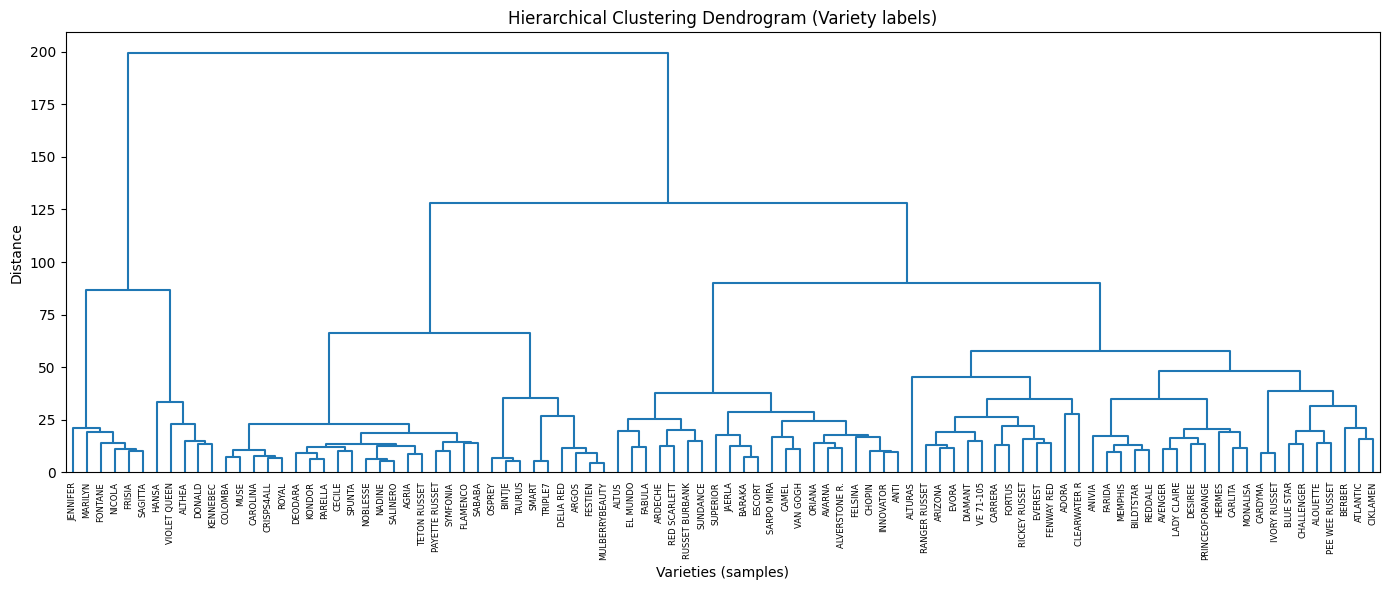

In [ ]:
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster



X = samples_with_variety.pivot_table(
    index="Filename",
    columns="Peak",
    values="Log10_normalized",  # or Intensity_corrected
    aggfunc="mean"
).fillna(0)

X_scaled = StandardScaler().fit_transform(X)

# Linkage for hierarchical clustering 
Z = linkage(X_scaled, method="ward")

# - Assign clusters 
clusters = fcluster(Z, t=5, criterion="maxclust")

# Merge cluster labels + variety
hca_results = pd.DataFrame({
    "Filename": X.index,
    "Cluster": clusters
}).merge(
    samples_with_variety[["Filename", "Variety"]].drop_duplicates(),
    on="Filename", how="left"
)

print("First few assignments:")
print(hca_results.head(15))

# Plot dendrogram with variety names
plt.figure(figsize=(14,6))
dendrogram(
    Z, 
    labels=hca_results["Variety"].tolist(),  # show variety instead of filename
    leaf_rotation=90, 
    leaf_font_size=6,
    color_threshold=0  
)
plt.title("Hierarchical Clustering Dendrogram (Variety labels)")
plt.xlabel("Varieties (samples)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


Reveals blocks of peaks that vary together across groups of varieties

# Cluster validation

In [ ]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist


# Hierarchical clustering linkage
Z = linkage(X_scaled, method="ward")

# Cophenetic correlation
coph_corr, _ = cophenet(Z, pdist(X_scaled))
print(f"Cophenetic correlation coefficient = {coph_corr:.3f}")

# Silhouette score for 2–10 clusters
for k in range(2, 10):
    labels = fcluster(Z, k, criterion="maxclust")
    sil = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={sil:.3f}")

Cophenetic correlation coefficient = 0.732
k=2, silhouette=0.479
k=3, silhouette=0.238
k=4, silhouette=0.236
k=5, silhouette=0.259
k=6, silhouette=0.251
k=7, silhouette=0.252
k=8, silhouette=0.237
k=9, silhouette=0.244


In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster


Z = linkage(X_scaled, method="ward")

# Choose number of clusters (based on silhouette, best was k=6 at 0.253)
k_opt = 2
cluster_labels = fcluster(Z, k_opt, criterion="maxclust")

# Add cluster labels to PCA scores dataframe
scores_df["Cluster"] = cluster_labels

# Plot PCA scatter with clusters
import plotly.express as px



fig = px.scatter(
    scores_df,
    x="PC1", y="PC2",
    color="Cluster",
    hover_data=["Variety"],  # adjust to your metadata column
    title=f"PCA with Hierarchical Clusters (k={k_opt}, silhouette={sil:.3f})",
    labels={
        "PC1": f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)",
        "PC2": f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)",
    }
)

fig.update_traces(marker=dict(size=8, opacity=0.7))

# Make the figure less wide (e.g., square-ish)
fig.update_layout(
    width=900,   # adjust width
    height=700,  # adjust height
    legend=dict(title="Clusters", itemsizing="constant")
)

fig.show()






# PLS-DA with VIP scores(strong contributers)

     Peak       VIP
526   527  1.920135
551   552  1.863245
549   550  1.785728
552   553  1.714138
573   574  1.700711
554   555  1.682556
556   557  1.678133
525   526  1.673934
553   554  1.661229
521   522  1.654028


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_1464\702947410.py:46: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



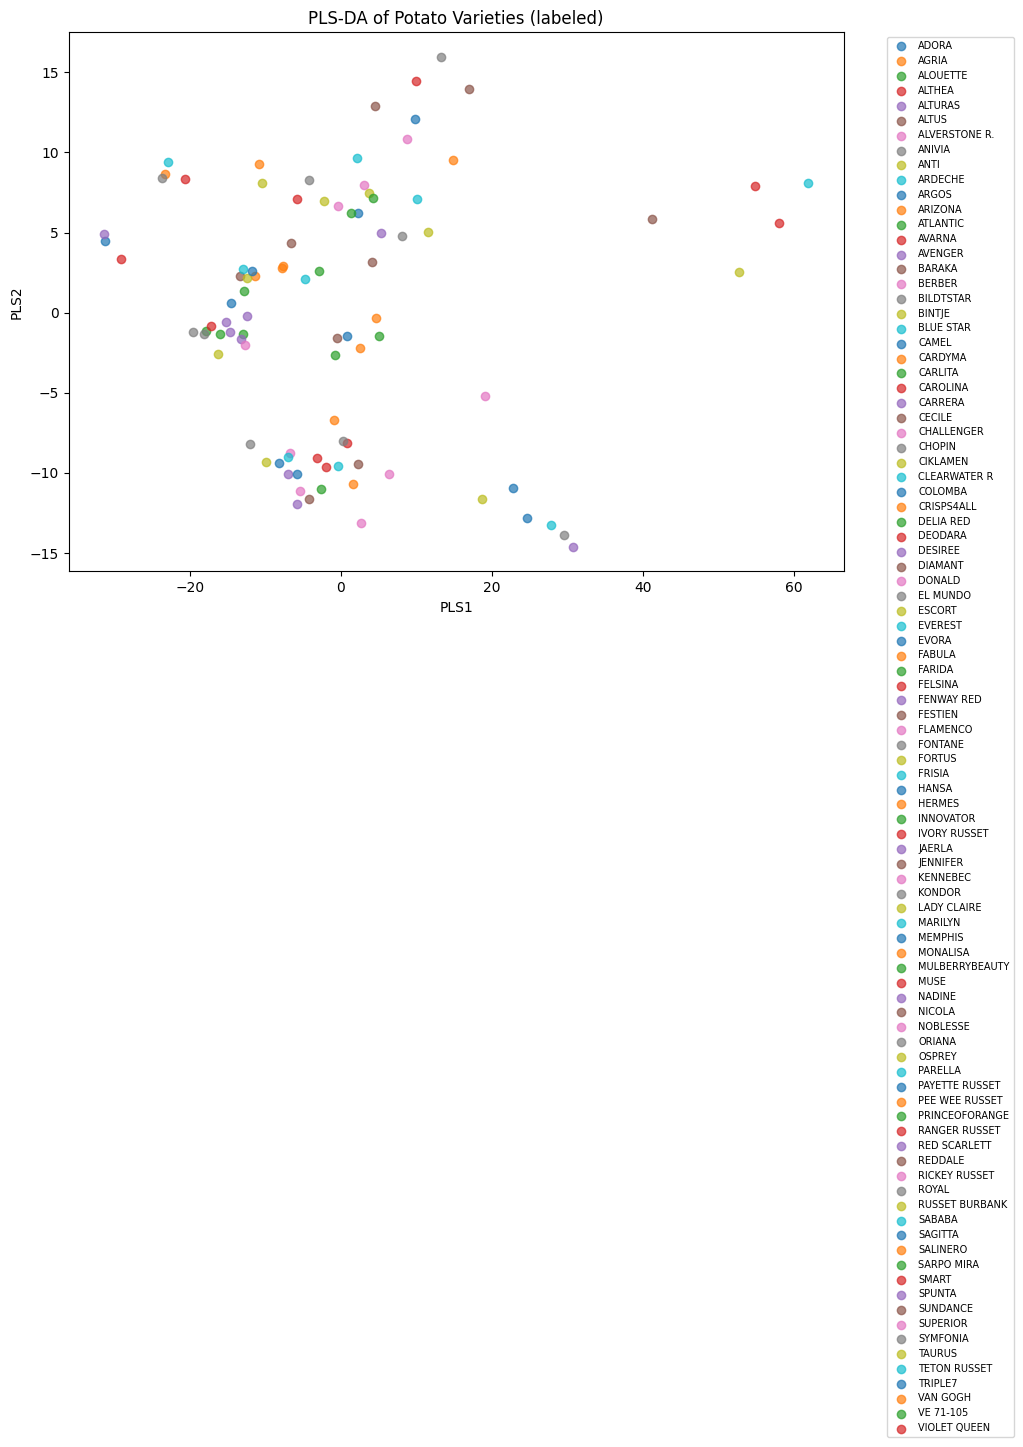

In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder



# Encode group labels 
y = samples_with_variety.drop_duplicates("Filename")["Variety"]
y_encoded = LabelEncoder().fit_transform(y)

#  PLS-DA model
pls = PLSRegression(n_components=2)
X_scores, Y_scores = pls.fit_transform(X, pd.get_dummies(y_encoded))


# VIP scores (importance of peaks) 
T = X_scores
W = pls.x_weights_
Q = pls.y_loadings_

# Compute VIP
p, h = W.shape
vip_scores = np.zeros((p,))
s = np.diag(T.T @ T @ Q.T @ Q).reshape(h, -1)
total_s = np.sum(s)

for i in range(p):
    weight = np.array([ (W[i,j]**2) * s[j] for j in range(h) ])
    vip_scores[i] = np.sqrt(p * np.sum(weight) / total_s)

vip_df = pd.DataFrame({"Peak": X.columns, "VIP": vip_scores})
vip_df = vip_df.sort_values("VIP", ascending=False)
print(vip_df.head(10))  # Top 10 discriminant peaks
# Map back encoded labels to actual variety names
label_map = dict(zip(LabelEncoder().fit(y).transform(y), y))
unique_labels = np.unique(y_encoded)

plt.figure(figsize=(10,7))
for u in unique_labels:
    mask = y_encoded == u
    plt.scatter(X_scores[mask,0], X_scores[mask,1], label=label_map[u], alpha=0.7)

plt.xlabel("PLS1")
plt.ylabel("PLS2")
plt.title("PLS-DA of Potato Varieties (labeled)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()


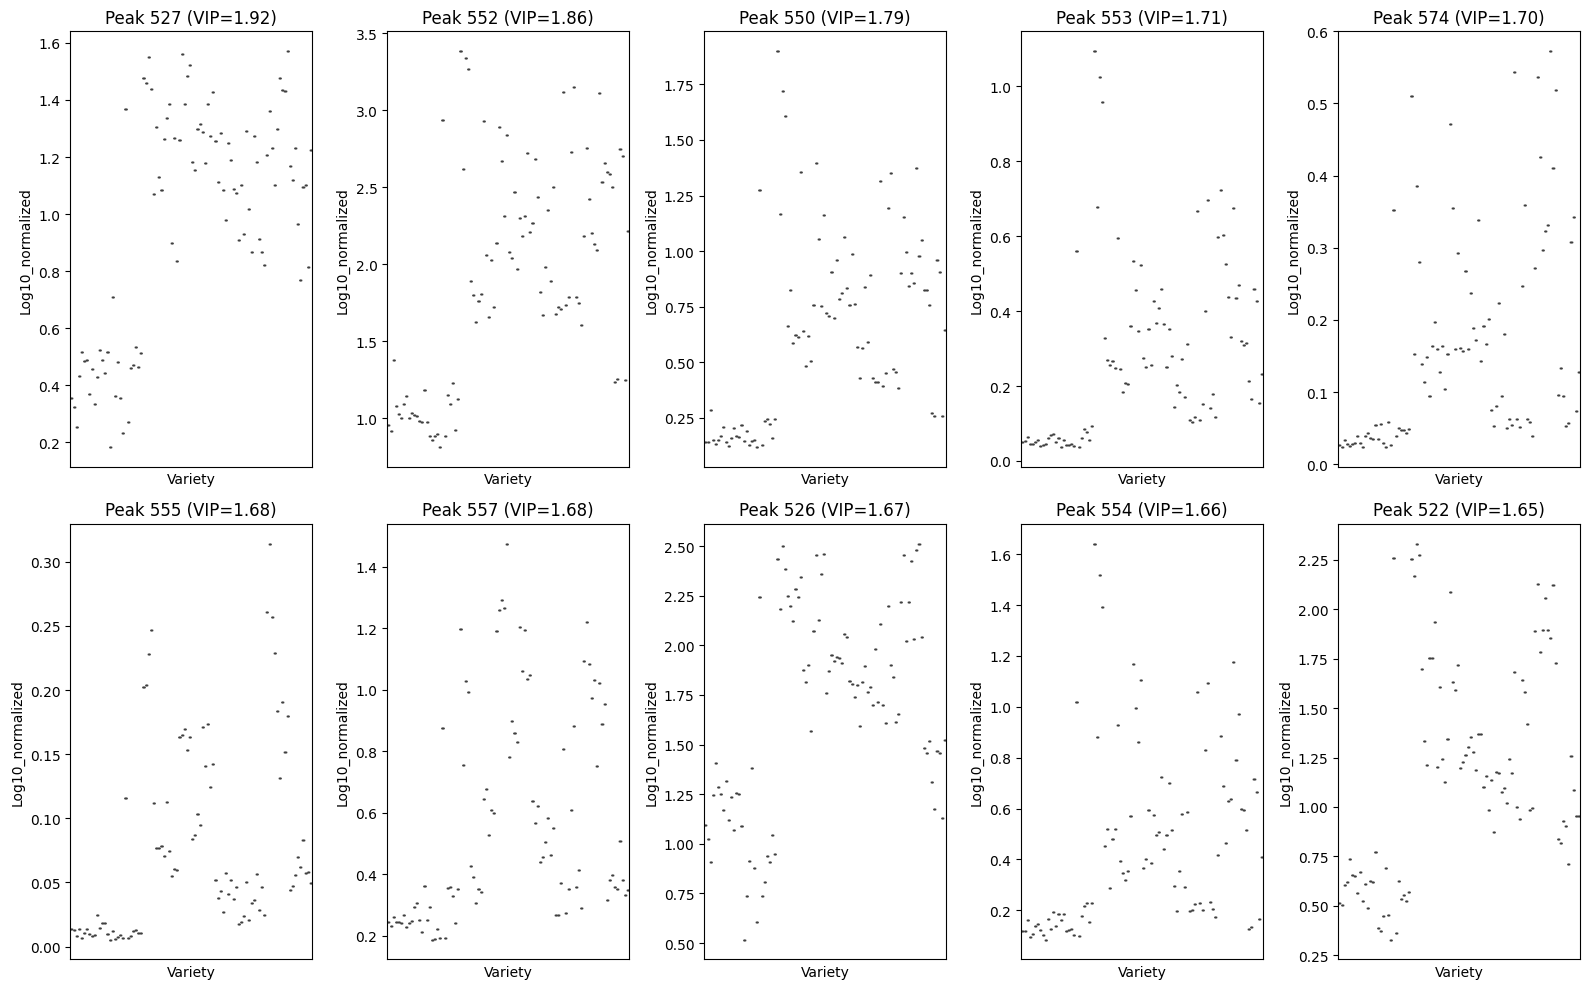

In [ ]:

vip_df = pd.DataFrame({
    "Peak": X.columns,  
    "VIP": vip_scores
})

# Sort by VIP
top_vip_peaks = vip_df.sort_values("VIP", ascending=False).head(10)["Peak"].tolist()

# Filter dataset for only those peaks
subset = samples_with_variety[samples_with_variety["Peak"].isin(top_vip_peaks)]


plt.figure(figsize=(16,10))
for i, peak in enumerate(top_vip_peaks, 1):
    plt.subplot(2, 5, i)
    sns.boxplot(
        data=subset[subset["Peak"] == peak],
        x="Variety", y="Log10_normalized",
        showfliers=False
    )
    plt.xticks([], [])  # hide variety names (too many)
    vip_val = vip_df.set_index("Peak").loc[peak,"VIP"]
    plt.title(f"Peak {peak} (VIP={vip_val:.2f})")
plt.tight_layout()
plt.show()


In [ ]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px

# Prepare initial data
available_varieties = subset["Variety"].unique()
top_peaks = top_vip_peaks[:10]  # limit to top 10 VIPs for dashboard

# Initialize the app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Variety Comparison Dashboard", style={"textAlign": "center"}),

    # Dropdown to select varieties
    dcc.Dropdown(
        id="variety-selector",
        options=[{"label": v, "value": v} for v in available_varieties],
        value=["ATLANTIC", "INNOVATOR"],  # default selection
        multi=True,
        style={"width": "60%"}
    ),

    # Dropdown to select peak
    dcc.Dropdown(
        id="peak-selector",
        options=[{"label": f"Peak {p}", "value": p} for p in top_peaks],
        value=top_peaks[0],
        style={"width": "60%", "marginTop": "10px"}
    ),

    # Graph
    dcc.Graph(id="boxplot")
])

@app.callback(
    Output("boxplot", "figure"),
    Input("variety-selector", "value"),
    Input("peak-selector", "value")
)
def update_boxplot(selected_varieties, selected_peak):
    filtered = subset[
        (subset["Variety"].isin(selected_varieties)) &
        (subset["Peak"] == selected_peak)
    ]

    # Safeguard: if no data, return empty plot
    if filtered.empty:
        return px.box(title="No data available for this selection")

    vip_value = vip_df.set_index("Peak").loc[selected_peak, "VIP"]

    fig = px.box(
        filtered,
        x="Variety",
        y="Log10_normalized",   # <-- FIXED
        color="Variety",
        title=f"Peak {selected_peak} (VIP={vip_value:.2f})",
        points="all"
    )
    fig.update_layout(xaxis_tickangle=45)
    return fig

if __name__ == "__main__":
    app.run(debug=True)


# Heatmap of Discriminant Peaks (ANOVA + clustering)

<Figure size 1200x800 with 0 Axes>

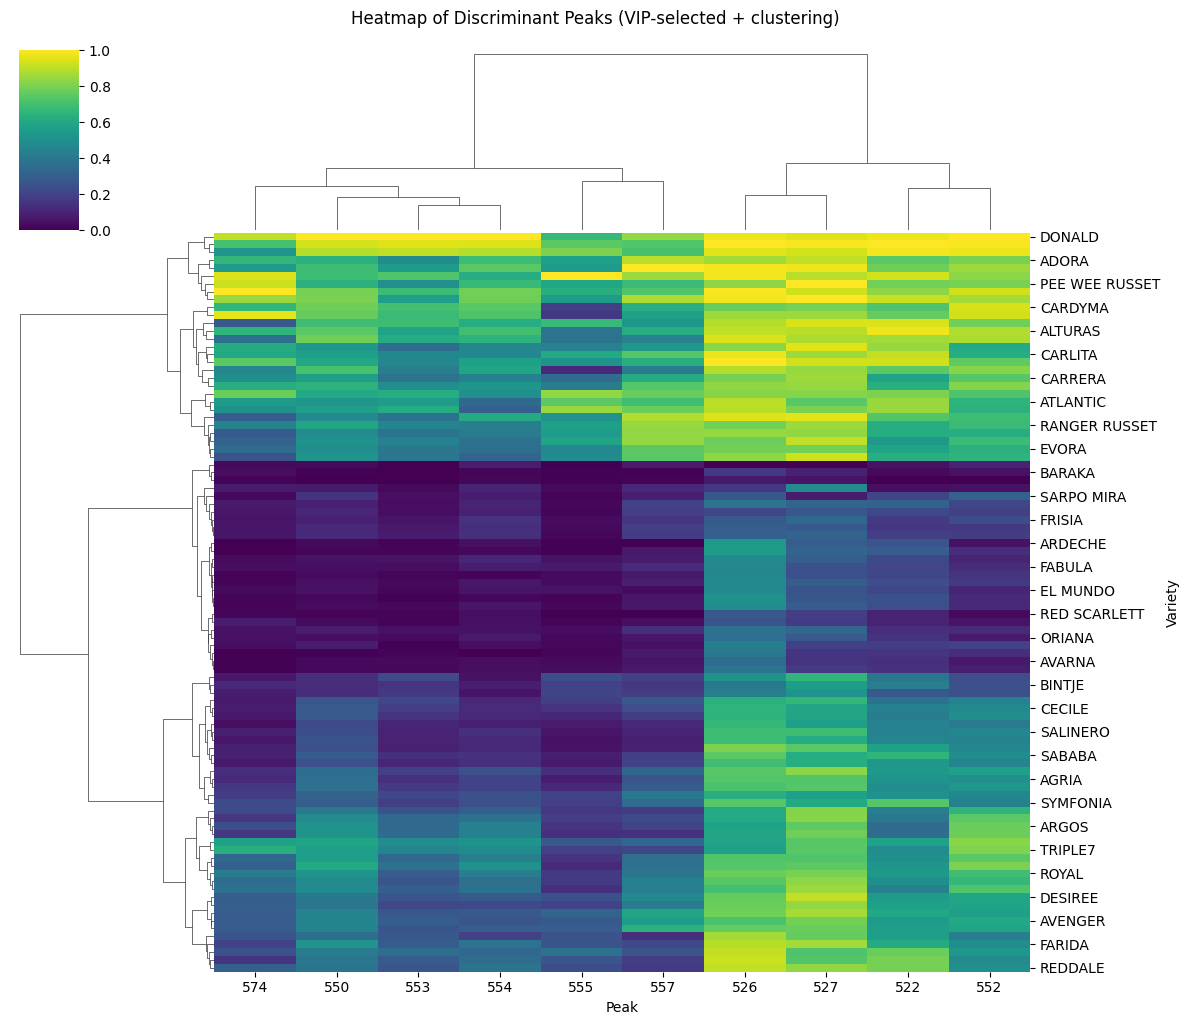

In [ ]:


discriminant_peaks = [ 527,552,550,553,574,555,557,526,554,522]

# Subset  normalized data for these peaks
subset = samples_with_variety[samples_with_variety["Peak"].isin(discriminant_peaks)]

# Pivot into wide matrix (samples × peaks)
heatmap_data = subset.pivot_table(
    index="Variety",   # rows = varieties
    columns="Peak",    # columns = discriminant peaks
    values="Log10_normalized",
    aggfunc="mean"     # average over replicates
).fillna(0)

# Log-transform for better scaling
import numpy as np
heatmap_data_log = np.log10(heatmap_data + 1)

#  heatmap with clustering 
plt.figure(figsize=(12,8))
sns.clustermap(
    heatmap_data_log,
    cmap="viridis",
    standard_scale=1,       # normalize per peak
    method="ward",
    metric="euclidean",
    figsize=(12,10)
)
plt.suptitle("Heatmap of Discriminant Peaks (VIP-selected + clustering)", y=1.02)
plt.show()


Fontane, Frisia, Jennifer, Donald, Cardyma cluster together at the top have high levels of these discriminant peaks.
Van Gogh, Chopin, Avarna  lower intensities of these same peaks

# Multidimensional Scaling (MDS)

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_1464\1378651111.py:39: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



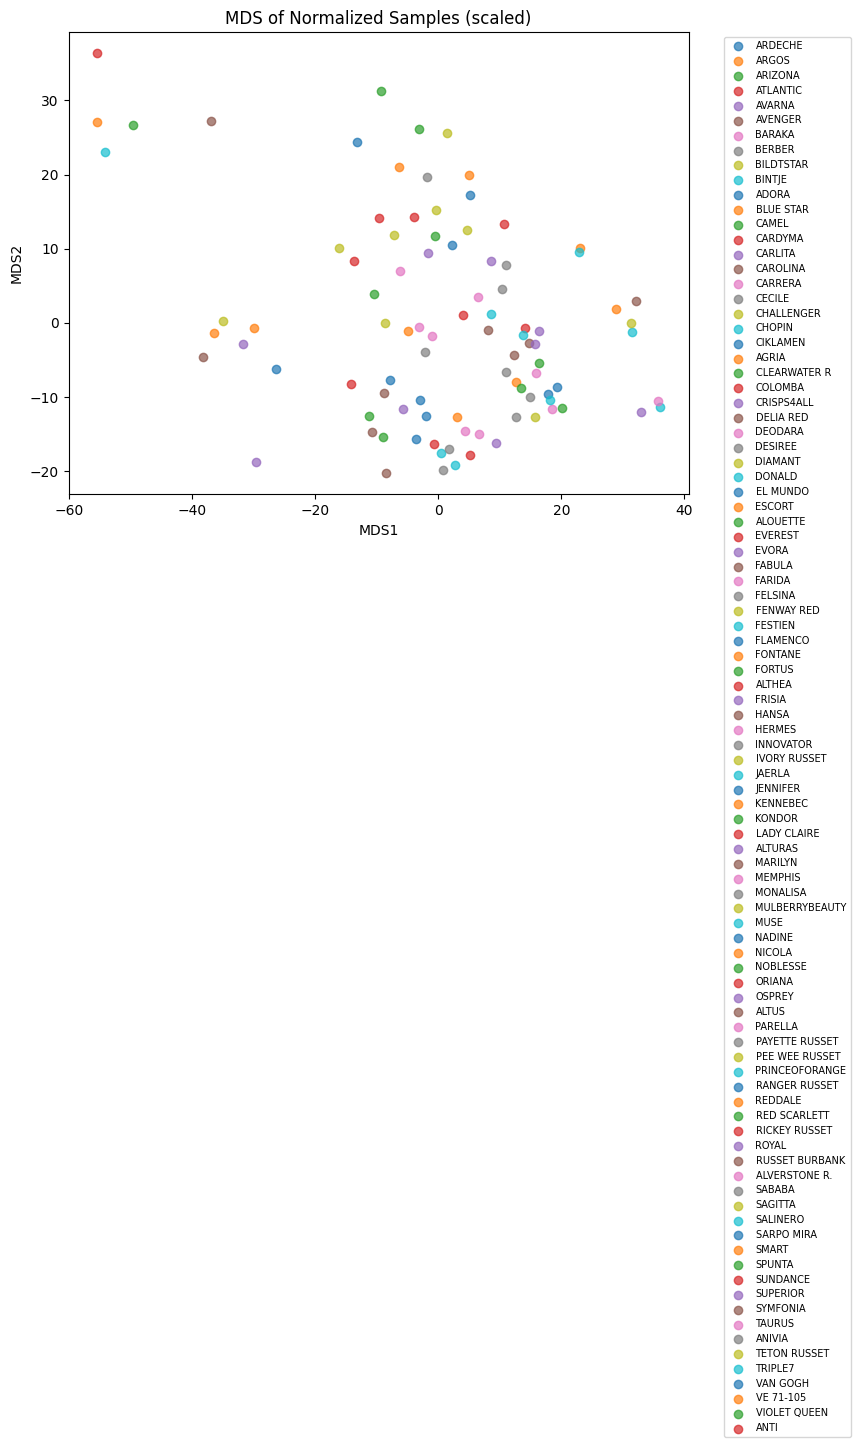

In [ ]:

from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances

#Pivot to wide sample × peak matrix 
X = samples_with_variety.pivot_table(
    index="Filename",
    columns="Peak",
    values="Log10_normalized",
    aggfunc="mean"
).fillna(0)

#  Scale before distance 
X_scaled = StandardScaler().fit_transform(X)

# Pairwise distances 
dist_matrix = pairwise_distances(X_scaled, metric="euclidean")

#  MDS 
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
mds_coords = mds.fit_transform(dist_matrix)

#  Merge with variety info 
mds_df = pd.DataFrame(mds_coords, columns=["MDS1", "MDS2"], index=X.index)
mds_df = mds_df.merge(
    samples_with_variety[["Filename", "Variety"]].drop_duplicates(),
    left_index=True, right_on="Filename"
)

# Plot 
plt.figure(figsize=(8,6))
for variety in mds_df["Variety"].unique():
    sub = mds_df[mds_df["Variety"] == variety]
    plt.scatter(sub["MDS1"], sub["MDS2"], label=variety, alpha=0.7)

plt.title("MDS of Normalized Samples (scaled)")
plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()
